# Toronto Raptors player EDA: offense, movement, and scoring precursors

This notebook builds interpretable player summaries for the ten tracked 2015–16 Raptors games. It is intentionally descriptive: it does **not** fit the QUT spatial model or estimate causal player effects. Player IDs remain internal join keys; names lead every displayed table and figure.

The analysis has three linked units:

1. a corrected Raptors offensive possession;
2. a physical SportVU moment and the five Raptors on court;
3. an NBA play-by-play event with a named actor.

The primary cohort retains all 883 corrected possessions with tracking. The existing 758-possession half-court cohort remains available as a sensitivity comparison. This choice follows the read-only audit below: the current half-court rule is outcome-dependent and should be treated as a quality flag until it is replaced by a sustained-crossing rule.

**Execution note.** This visualization/documentation edit is not re-executed. Run cells in order. The raw JSON parsing cell is the expensive step; no intermediate files are written unless `SAVE_INTERMEDIATE = True`.

In [26]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")

RAPTORS_TEAM_ID = 1610612761
COURT_LENGTH_FT = 94.0
COURT_WIDTH_FT = 50.0

# Primary estimates use every represented corrected possession. Change to
# "current_half_court_filter" only for direct replication of the downstream file.
PRIMARY_COHORT = "all_represented"
SAVE_INTERMEDIATE = False

# Transparent tracking thresholds; sensitivity results are produced below.
BALL_CONTROL_RADIUS_FT = 4.0
BALL_CONTROL_MAX_HEIGHT_FT = 8.0
MAX_LIVE_FRAME_GAP_SECONDS = 0.25
MAX_PLAYER_SPEED_FT_PER_SECOND = 35.0
MAX_RECOVERY_TO_OFFENSE_ALIGNMENT_GAP_SECONDS = 12.0

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "multi_game_data":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRACKING_DIR = PROJECT_ROOT / "multi_game_data"
FULL_BALL_PATH = TRACKING_DIR / "multi_game_data.csv"
FILTERED_BALL_PATH = TRACKING_DIR / "multi_game_data_half_court_filtered.csv"
PBP_PATH = PROJECT_ROOT / "nbastats_2015.csv"
COURT_IMAGE_PATH = PROJECT_ROOT / "court.jpg"

required_paths = [
    FULL_BALL_PATH,
    FILTERED_BALL_PATH,
    PBP_PATH,
    COURT_IMAGE_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing required inputs: {missing_paths}")

GAME_JSON_PATHS = sorted(TRACKING_DIR.glob("00215*.json"))
if not GAME_JSON_PATHS:
    raise FileNotFoundError(f"No tracking JSON files found in {TRACKING_DIR}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Tracking games found: {len(GAME_JSON_PATHS)}")

Project root: C:\Users\Jonathan\anaconda_projects\NBA Analysis\Spatial Reconstruction of NBA Games
Tracking games found: 10


## Definitions and interpretation

Let possession (i) contain physical tracking moments (t=1,\ldots,T_i), and let (p) denote a player.

**Live interval.** With game clock (c_t) counting down, the duration represented by moment (t) is

\begin{aligned}
\\ \Delta t_t = c_t-c_{t+1}.
\end{aligned}

We retain $0<\Delta t_t\le 0.25$ seconds. Paused-clock rows and larger feed gaps do not contribute exposure or distance.

**Movement.** If $(x_{pt},y_{pt})$ is the player's normalized court position, then

\begin{aligned}
\\d_{pt}=\sqrt{(x_{p,t+1}-x_{pt})^2+(y_{p,t+1}-y_{pt})^2}.
\end{aligned}

A movement step is accepted only when $d_{pt}/\Delta t_t\le35$ ft/s. Player distance is $D_{pi}=\sum_t d_{pt}$; average speed is $D_{pi}/\sum_t\Delta t_t$.

**Ball-control time (tracking proxy).** Let $r_{pt}$ be planar distance from player $p$ to the ball. At each moment, control is assigned to the nearest Raptor only when

\begin{aligned}
\\ r_{pt}\le4\text{ ft}\quad\text{and}\quad z^{ball}_t\le8\text{ ft}.
\end{aligned}

This is not an official touch or time-of-possession statistic: passes, loose balls, rebounds, and occlusion create unassigned time. Results at 3, 4, and 5 feet are compared below. No temporal or total-variation smoothing is applied.

**Official event metrics.** Points, assists, steals, blocks, and rebounds come from play-by-play actors, not spatial inference. Offensive and defensive rebound types are recovered from the event's cumulative `Off` and `Def` counters.

**Scoring precursor.** A steal or defensive rebound is linked to the next Raptors offensive possession in the same period. Because the possession-table clock endpoints lag the event clock in some sequences, the primary alignment permits a gap of at most 12 seconds and reports linkage sensitivity at 3, 5, 8, and 12 seconds. A block is credited only when a subsequent Toronto recovery links to that possession. An offensive rebound is successful only if Toronto scores later in the same possession. These are next-possession associations, not causal effects.

## Read-only audit of `multi_game_analysis.ipynb`

This notebook does not modify the existing multi-game notebook or either master CSV. The cells below reproduce the current filter and add sensitivity checks.

### Output guide: possession cohort audit

`cohort_summary` has one row per audit measure and one numeric column, `count`. `represented possessions` is the number available in the loaded ball CSV; `current half-court-filtered possessions` is the subset present in the historical filtered CSV; `primary analysis possessions` reflects `PRIMARY_COHORT`; `known external scoring-label mismatches` counts the two documented technical-free-throw errors; and the two point rows sum the current possession labels before and after the historical filter. These are cohort totals, not player statistics.

In [27]:
POSSESSION_KEY = ["game_id", "period", "possession_number"]

full_ball = pd.read_csv(FULL_BALL_PATH, dtype={"game_id": str})
filtered_ball = pd.read_csv(FILTERED_BALL_PATH, dtype={"game_id": str})
for frame in (full_ball, filtered_ball):
    frame["game_id"] = frame["game_id"].str.zfill(10)

possession_table = (
    full_ball.groupby(POSSESSION_KEY, as_index=False, sort=True)
    .agg(
        possession_start=("possession_start", "first"),
        possession_end=("possession_end", "first"),
        points_scored=("points_scored", "first"),
        scored=("scored", "first"),
        is_home=("is_home", "first"),
        tracking_rows=("time", "size"),
    )
)
possession_table["duration_seconds"] = (
    possession_table["possession_start"] - possession_table["possession_end"]
)
possession_table["start_elapsed_seconds"] = (
    possession_table["period"] * 720 - possession_table["possession_start"]
)
possession_table["end_elapsed_seconds"] = (
    possession_table["period"] * 720 - possession_table["possession_end"]
)

current_kept_keys = filtered_ball[POSSESSION_KEY].drop_duplicates().assign(
    current_half_court_keep=True
)
possession_table = possession_table.merge(
    current_kept_keys,
    on=POSSESSION_KEY,
    how="left",
    validate="one_to_one",
)
possession_table["current_half_court_keep"] = possession_table[
    "current_half_court_keep"
].eq(True)

# External PBP reconciliation identified two current labels that credit an
# opponent technical free throw to Toronto. Preserve them for spatial exposure,
# but exclude them from success/failure contrasts in this notebook.
known_scoring_mismatch_keys = pd.DataFrame(
    [
        {"game_id": "0021500355", "period": 3, "possession_number": 59},
        {"game_id": "0021500540", "period": 2, "possession_number": 32},
    ]
).assign(known_external_scoring_mismatch=True)
possession_table = possession_table.merge(
    known_scoring_mismatch_keys,
    on=POSSESSION_KEY,
    how="left",
    validate="one_to_one",
)
possession_table["known_external_scoring_mismatch"] = possession_table[
    "known_external_scoring_mismatch"
].eq(True)

if PRIMARY_COHORT == "all_represented":
    analysis_possessions = possession_table.copy()
elif PRIMARY_COHORT == "current_half_court_filter":
    analysis_possessions = possession_table.loc[
        possession_table["current_half_court_keep"]
    ].copy()
else:
    raise ValueError(f"Unknown PRIMARY_COHORT={PRIMARY_COHORT!r}")

cohort_summary = pd.Series(
    {
        "represented possessions": len(possession_table),
        "current half-court-filtered possessions": int(
            possession_table["current_half_court_keep"].sum()
        ),
        "primary analysis possessions": len(analysis_possessions),
        "known external scoring-label mismatches": int(
            possession_table["known_external_scoring_mismatch"].sum()
        ),
        "represented current-label points": int(possession_table["points_scored"].sum()),
        "current-filter current-label points": int(
            possession_table.loc[
                possession_table["current_half_court_keep"], "points_scored"
            ].sum()
        ),
    },
    name="count",
)
display(cohort_summary.to_frame())

,count
represented possessions,882
current half-court-filtered possessions,757
primary analysis possessions,882
known external scoring-label mismatches,2
represented current-label points,968
current-filter current-label points,899


### Output guides: crossing sensitivity and historical-filter composition

**`crossing_sensitivity`**

- `rule`: dead-band and minimum-dwell definition used to count stable side changes at half court.
- `flagged_possessions`: possessions with at least two crossings under that rule.
- `retained_possessions`: possessions with fewer than two crossings; flagged plus retained equals the represented cohort.

**`filter_comparison`**

- `cohort`: whether the historical half-court filter retained or removed the possession.
- `possessions`: distinct possession rows in that cohort-level table.
- `points`: Toronto possession-label points summed over the cohort.
- `scoring_rate`: fraction of possessions with at least one point.
- `mean_duration_seconds`, `median_duration_seconds`: elapsed possession duration summaries; the median is less sensitive to long rebound/reset sequences.

In [28]:
def count_half_court_crossings(
    group: pd.DataFrame,
    deadband_ft: float = 0.0,
    minimum_dwell_seconds: float = 0.0,
) -> int:
    """Count sustained side changes around x=47 in raw court coordinates."""
    ordered = group.sort_values("time", ascending=False)
    x = ordered["x"]
    if deadband_ft == 0:
        side = np.sign(x - 47).replace(0, np.nan)
    else:
        side = pd.Series(
            np.where(
                x < 47 - deadband_ft,
                -1,
                np.where(x > 47 + deadband_ft, 1, np.nan),
            ),
            index=x.index,
        )
    side = side.ffill().bfill()
    if side.empty or side.isna().all():
        return 0

    run_id = side.ne(side.shift()).cumsum()
    runs = (
        pd.DataFrame({"side": side, "time": ordered["time"]})
        .groupby(run_id, as_index=False)
        .agg(side=("side", "first"), max_time=("time", "max"), min_time=("time", "min"))
    )
    runs["dwell_seconds"] = runs["max_time"] - runs["min_time"]
    if minimum_dwell_seconds > 0:
        runs = runs.loc[runs["dwell_seconds"] >= minimum_dwell_seconds]
    if runs.empty:
        return 0
    stable_side = runs["side"].loc[runs["side"].ne(runs["side"].shift())]
    return max(0, len(stable_side) - 1)


crossing_specs = [
    ("current: no deadband/dwell", 0.0, 0.0),
    ("2 ft deadband", 2.0, 0.0),
    ("2 ft + 0.25 s dwell", 2.0, 0.25),
    ("2 ft + 0.50 s dwell", 2.0, 0.50),
    ("2 ft + 1.00 s dwell", 2.0, 1.00),
]

crossing_results = []
grouped_ball = full_ball.groupby(POSSESSION_KEY, sort=False)
for label, deadband, dwell in crossing_specs:
    counts = grouped_ball.apply(
        count_half_court_crossings,
        deadband_ft=deadband,
        minimum_dwell_seconds=dwell,
        include_groups=False,
    )
    crossing_results.append(
        {
            "rule": label,
            "flagged_possessions": int((counts >= 2).sum()),
            "retained_possessions": int((counts < 2).sum()),
        }
    )

crossing_sensitivity = pd.DataFrame(crossing_results)
display(crossing_sensitivity)

filter_comparison = (
    possession_table.assign(
        cohort=np.where(
            possession_table["current_half_court_keep"], "retained", "removed"
        )
    )
    .groupby("cohort", as_index=False)
    .agg(
        possessions=("possession_number", "size"),
        points=("points_scored", "sum"),
        scoring_rate=("scored", "mean"),
        mean_duration_seconds=("duration_seconds", "mean"),
        median_duration_seconds=("duration_seconds", "median"),
    )
)
display(filter_comparison.round(3))

C:\Users\Jonathan\AppData\Local\Temp\ipykernel_24948\3203139900.py:28: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(side=("side", "first"), max_time=("time", "max"), min_time=("time", "min"))
C:\Users\Jonathan\AppData\Local\Temp\ipykernel_24948\3203139900.py:28: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(side=("side", "first"), max_time=("time", "max"), min_time=("time", "min"))
C:\Users\Jonathan\AppData\Local\Temp\ipykernel_24948\3203139900.py:28: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This gr

,rule,flagged_possessions,retained_possessions
0,current: no deadband/dwell,122,760
1,2 ft deadband,97,785
2,2 ft + 0.25 s dwell,76,806
3,2 ft + 0.50 s dwell,62,820
4,2 ft + 1.00 s dwell,41,841


,cohort,possessions,points,scoring_rate,mean_duration_seconds,median_duration_seconds
0,removed,125,69,0.248,23.096,23.0
1,retained,757,899,0.559,15.692,16.0


### Audit findings and recommendations

The stored outputs and master files reconcile as follows:

| Stage | Possessions | Raptors points | Assessment |
|---|---:|---:|---|
| Corrected metadata | 902 | 1,001 current labels | 13 confirmed one-point continuations were merged from 915 source segments; internal point labels are preserved. |
| Spatially eligible | 894 | 988 current labels | 8 zero-duration/stopped-clock possessions are excluded. This is necessary for movement integration. |
| Tracking represented | 883 | 972 current labels | 11 intervals fall inside genuine holes in the JSON feeds. Spatial exclusion is necessary, but they should remain in non-spatial summaries. |
| Current half-court filter | 758 | 901 | 125 represented possessions and 71 points are removed. This final deletion is not presently justified as a hard exclusion. |

Specific checks:

- The source-to-corrected possession mapping, composite `(game, possession)` keys, and scoring-label reconciliation work as intended.
- External play-by-play reconciliation finds 999 official Raptors player points, not the 1,001 points in the possession files. Games `0021500355` and `0021500540` each assign one opponent technical-free-throw point to Toronto. The affected tracked possessions are game `0021500355`, possession 59 and game `0021500540`, possession 32; both happen to be removed by the current half-court filter. Official player points below therefore come from play-by-play, while spatial success/failure retains the current possession label for downstream comparability and flags this limitation.
- The 11 missing intervals have no raw tracking moments inside their clock bounds; this is missing-feed coverage rather than a merge failure.
- The current `x=47` crossing rule has no dead band or dwell requirement. A 2-foot dead band plus 0.5-second stable-side requirement flags 62 possessions instead of 125.
- Removed possessions have a 26.4% scoring rate and mean duration 23.1 seconds; retained possessions have a 55.9% scoring rate and mean duration 15.7 seconds. Hard deletion therefore changes the outcome distribution and can bias scoring analysis.
- Fourteen `(game, period, game-clock)` values occur at boundaries of two possessions because extraction uses inclusive bounds. Use half-open intervals and the physical millisecond timestamp for new work.
- Raw JSON clips contain many exact duplicate timestamps. They are normally identical, but one conflicting duplicate timestamp occurs in game `0021500390`. New code below deduplicates on the physical timestamp, keeps the last record deterministically, and reports conflicts.
- The current orientation makes the common Toronto attacking basket point left-to-right. It does **not** imply that every ball path is monotone; retreats, passes, deflections, and turnovers can move left.
- The conversion `period * 720 - elapsed` is valid for these regulation-only games. It needs a five-minute-period branch before overtime games are added.

Recommendation: keep all 883 represented possessions for primary player EDA, retain the current 758-possession indicator for sensitivity, and do not change `multi_game_analysis.ipynb` until sustained-crossing cases have been visually adjudicated.

## Official play-by-play player metrics

Event codes are used only after filtering to the ten tracked games. Actor fields have standard roles in this file: shooter/rebounder in `PLAYER1`, assister or stealer in `PLAYER2`, and blocker in `PLAYER3`. `PCTIMESTRING` is cumulative game time in 1/60-second ticks despite its label.

### Output guide: play-by-play coverage

The displayed event-coverage table has one row per tracked game. `game_id` is the zero-padded NBA game identifier; `events` counts all play-by-play rows loaded for that game; and `periods` counts distinct periods represented. It verifies coverage only—it is not a player box score.

In [29]:
PBP_COLUMNS = [
    "GAME_ID",
    "EVENTNUM",
    "EVENTMSGTYPE",
    "EVENTMSGACTIONTYPE",
    "PERIOD",
    "PCTIMESTRING",
    "HOMEDESCRIPTION",
    "NEUTRALDESCRIPTION",
    "VISITORDESCRIPTION",
    "SCORE",
    "PLAYER1_ID",
    "PLAYER1_NAME",
    "PLAYER1_TEAM_ID",
    "PLAYER2_ID",
    "PLAYER2_NAME",
    "PLAYER2_TEAM_ID",
    "PLAYER3_ID",
    "PLAYER3_NAME",
    "PLAYER3_TEAM_ID",
]

game_ids = sorted(possession_table["game_id"].unique())
game_ids_numeric = {int(game_id) for game_id in game_ids}

events = pd.read_csv(PBP_PATH, usecols=PBP_COLUMNS)
events = events.loc[events["GAME_ID"].isin(game_ids_numeric)].copy()
events["game_id"] = events["GAME_ID"].astype("int64").astype(str).str.zfill(10)
events = events.sort_values(["game_id", "EVENTNUM"]).reset_index(drop=True)
events["event_elapsed_seconds"] = pd.to_numeric(
    events["PCTIMESTRING"], errors="coerce"
) / 60.0
events["event_clock"] = events["PERIOD"] * 720 - events["event_elapsed_seconds"]

description_columns = [
    "HOMEDESCRIPTION",
    "NEUTRALDESCRIPTION",
    "VISITORDESCRIPTION",
]
events["description"] = (
    events[description_columns]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.replace(r"(?:\s*\|\s*)+", " | ", regex=True)
    .str.strip(" |")
)

for column in [
    "PLAYER1_ID",
    "PLAYER1_TEAM_ID",
    "PLAYER2_ID",
    "PLAYER2_TEAM_ID",
    "PLAYER3_ID",
    "PLAYER3_TEAM_ID",
]:
    events[column] = pd.to_numeric(events[column], errors="coerce").astype("Int64")

if events["game_id"].nunique() != len(game_ids):
    raise ValueError("Play-by-play coverage does not include every tracking game.")

display(
    events.groupby("game_id", as_index=False).agg(
        events=("EVENTNUM", "size"),
        periods=("PERIOD", "nunique"),
    )
)

,game_id,events,periods
0,0021500009,514,4
1,0021500057,492,4
2,0021500131,448,4
3,0021500188,418,4
4,0021500196,464,4
5,0021500272,446,4
6,0021500355,478,4
7,0021500390,397,4
8,0021500540,449,4
9,0021500649,421,4


### Output guide: official all-games player totals

`boxscore_all_games` displays one row per named Raptor. `games_with_recorded_stat` counts games in which the player recorded at least one of the extracted actions and therefore is **not** games played. `points`, `assists`, `steals`, `blocks`, `offensive_rebounds`, and `defensive_rebounds` are official event totals across the tracked games. `rebounds` is offensive plus defensive rebounds. Player IDs are retained internally but intentionally omitted from this display.

In [30]:
EVENT_STAT_COLUMNS = [
    "game_id",
    "EVENTNUM",
    "PERIOD",
    "event_elapsed_seconds",
    "event_clock",
    "player_id",
    "player_name",
    "stat",
    "value",
]


def actor_stat_rows(
    mask: pd.Series,
    actor_number: int,
    stat: str,
    value=1,
) -> pd.DataFrame:
    id_column = f"PLAYER{actor_number}_ID"
    name_column = f"PLAYER{actor_number}_NAME"
    selected = events.loc[
        mask & events[id_column].notna() & events[name_column].notna(),
        [
            "game_id",
            "EVENTNUM",
            "PERIOD",
            "event_elapsed_seconds",
            "event_clock",
            id_column,
            name_column,
        ],
    ].copy()
    selected = selected.rename(
        columns={id_column: "player_id", name_column: "player_name"}
    )
    selected["stat"] = stat
    if np.isscalar(value):
        selected["value"] = value
    else:
        selected["value"] = pd.Series(value, index=selected.index)
    selected["player_id"] = selected["player_id"].astype("int64")
    return selected[EVENT_STAT_COLUMNS]


descriptions_upper = events["description"].str.upper()

made_fg_mask = (
    events["EVENTMSGTYPE"].eq(1)
    & events["PLAYER1_TEAM_ID"].eq(RAPTORS_TEAM_ID)
)
made_fg_points = np.where(
    descriptions_upper.loc[made_fg_mask].str.contains(r"\b3PT\b", regex=True),
    3,
    2,
)

made_ft_mask = (
    events["EVENTMSGTYPE"].eq(3)
    & events["PLAYER1_TEAM_ID"].eq(RAPTORS_TEAM_ID)
    & ~descriptions_upper.str.contains(r"\bMISS\b", regex=True)
)

stat_frames = [
    actor_stat_rows(made_fg_mask, 1, "points", made_fg_points),
    actor_stat_rows(made_ft_mask, 1, "points", 1),
    actor_stat_rows(
        events["EVENTMSGTYPE"].eq(1)
        & events["PLAYER2_TEAM_ID"].eq(RAPTORS_TEAM_ID)
        & descriptions_upper.str.contains(r"\bAST\b", regex=True),
        2,
        "assists",
    ),
    actor_stat_rows(
        events["EVENTMSGTYPE"].eq(5)
        & events["PLAYER2_TEAM_ID"].eq(RAPTORS_TEAM_ID)
        & descriptions_upper.str.contains(r"\bSTEAL\b", regex=True),
        2,
        "steals",
    ),
    actor_stat_rows(
        events["EVENTMSGTYPE"].eq(2)
        & events["PLAYER3_TEAM_ID"].eq(RAPTORS_TEAM_ID)
        & descriptions_upper.str.contains(r"\bBLOCK\b", regex=True),
        3,
        "blocks",
    ),
]

raptors_rebounds = events.loc[
    events["EVENTMSGTYPE"].eq(4)
    & events["PLAYER1_TEAM_ID"].eq(RAPTORS_TEAM_ID)
    & events["PLAYER1_NAME"].notna()
    & events["PLAYER1_ID"].ne(RAPTORS_TEAM_ID)
].copy()
rebound_totals = raptors_rebounds["description"].str.extract(
    r"Off:(?P<off_total>\d+)\s+Def:(?P<def_total>\d+)",
    flags=re.IGNORECASE,
)
raptors_rebounds = pd.concat([raptors_rebounds, rebound_totals], axis=1)
raptors_rebounds[["off_total", "def_total"]] = raptors_rebounds[
    ["off_total", "def_total"]
].apply(pd.to_numeric, errors="coerce")
raptors_rebounds = raptors_rebounds.sort_values(
    ["game_id", "PLAYER1_ID", "EVENTNUM"]
)
for rebound_type in ["off", "def"]:
    total_column = f"{rebound_type}_total"
    previous = raptors_rebounds.groupby(["game_id", "PLAYER1_ID"])[
        total_column
    ].shift(fill_value=0)
    raptors_rebounds[f"{rebound_type}_increment"] = (
        raptors_rebounds[total_column] - previous
    ).clip(lower=0)


def rebound_stat_rows(increment_column: str, stat: str) -> pd.DataFrame:
    rebound_rows = raptors_rebounds.loc[
        raptors_rebounds[increment_column].gt(0),
        [
            "game_id",
            "EVENTNUM",
            "PERIOD",
            "event_elapsed_seconds",
            "event_clock",
            "PLAYER1_ID",
            "PLAYER1_NAME",
            increment_column,
        ],
    ].rename(
        columns={
            "PLAYER1_ID": "player_id",
            "PLAYER1_NAME": "player_name",
            increment_column: "value",
        }
    )
    rebound_rows["stat"] = stat
    rebound_rows["player_id"] = rebound_rows["player_id"].astype("int64")
    return rebound_rows[EVENT_STAT_COLUMNS]


stat_frames.extend(
    [
        rebound_stat_rows("off_increment", "offensive_rebounds"),
        rebound_stat_rows("def_increment", "defensive_rebounds"),
    ]
)

event_player_stats = pd.concat(stat_frames, ignore_index=True)

expected_stats = [
    "points",
    "assists",
    "steals",
    "blocks",
    "offensive_rebounds",
    "defensive_rebounds",
]
boxscore_by_player_game = (
    event_player_stats.pivot_table(
        index=["game_id", "player_id", "player_name"],
        columns="stat",
        values="value",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=expected_stats, fill_value=0)
    .reset_index()
)
boxscore_by_player_game["rebounds"] = (
    boxscore_by_player_game["offensive_rebounds"]
    + boxscore_by_player_game["defensive_rebounds"]
)

boxscore_all_games = (
    boxscore_by_player_game.groupby(["player_id", "player_name"], as_index=False)
    .agg(
        games_with_recorded_stat=("game_id", "nunique"),
        points=("points", "sum"),
        assists=("assists", "sum"),
        steals=("steals", "sum"),
        blocks=("blocks", "sum"),
        offensive_rebounds=("offensive_rebounds", "sum"),
        defensive_rebounds=("defensive_rebounds", "sum"),
        rebounds=("rebounds", "sum"),
    )
    .sort_values(["points", "assists"], ascending=False)
)

# Names lead the output; player_id remains available only as the stable join key.
display(boxscore_all_games.drop(columns="player_id"))

,player_name,games_with_recorded_stat,points,assists,steals,blocks,offensive_rebounds,defensive_rebounds,rebounds
2,DeMar DeRozan,10,239,37,10,2,8,47,55
1,Kyle Lowry,10,212,58,28,8,3,46,49
0,Luis Scola,10,132,6,7,2,12,47,59
6,Jonas Valanciunas,6,76,8,1,12,12,40,52
4,DeMarre Carroll,6,67,8,12,2,13,23,36
8,Cory Joseph,10,63,24,6,3,3,20,23
9,Terrence Ross,9,62,7,5,4,0,13,13
3,James Johnson,6,45,9,1,6,8,14,22
7,Bismack Biyombo,10,45,1,1,13,24,60,84
5,Patrick Patterson,10,42,7,6,2,8,32,40


### Output guide: scoring reconciliation

`point_reconciliation` has one row per game. `game_id` identifies the game; `possession_points` sums Toronto points in the source possession file; `event_points` sums named Toronto scoring events; and `difference = event_points - possession_points`. Zero indicates agreement, while a negative value means the possession labels attribute more points to Toronto than official named scoring events do.

In [31]:
# Reconcile event-derived points against the source possession files (all Raptors
# possessions, including those without tracking).
source_point_rows = []
for path in sorted(TRACKING_DIR.glob("*_possessions.csv")):
    source = pd.read_csv(path)
    source.columns = [
        "game_id",
        "possession_number",
        "period",
        "possession_start_elapsed",
        "possession_end_elapsed",
        "offense_team_id",
        "points_scored",
        "event_count",
    ]
    game_id = path.name.replace("_possessions.csv", "")
    raptors_points = source.loc[
        source["offense_team_id"].eq(RAPTORS_TEAM_ID), "points_scored"
    ].sum()
    source_point_rows.append({"game_id": game_id, "possession_points": raptors_points})

point_reconciliation = pd.DataFrame(source_point_rows).merge(
    event_player_stats.loc[event_player_stats["stat"].eq("points")]
    .groupby("game_id", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "event_points"}),
    on="game_id",
    how="left",
    validate="one_to_one",
)
point_reconciliation["difference"] = (
    point_reconciliation["event_points"] - point_reconciliation["possession_points"]
)
display(point_reconciliation)
if point_reconciliation["difference"].ne(0).any():
    print(
        "Audit warning: possession totals do not fully reconcile to official "
        "player scoring events. Keep official player points and current spatial "
        "outcomes as separate fields."
    )

,game_id,possession_points,event_points,difference
0,0021500009,106,106,0
1,0021500057,102,102,0
2,0021500131,100,100,0
3,0021500188,102,102,0
4,0021500196,91,91,0
5,0021500272,96,96,0
6,0021500355,97,96,-1
7,0021500390,108,108,0
8,0021500540,98,97,-1
9,0021500649,101,101,0


Audit warning: possession totals do not fully reconcile to official player scoring events. Keep official player points and current spatial outcomes as separate fields.


## Parse physical moments and identify the five Raptors on court

The JSON files repeat overlapping SportVU clips. `moment[1]` is the physical millisecond timestamp and is the correct identity key; `moment[2]` is the displayed game clock and can remain unchanged during a stoppage. We use the half-open interval

\[
c_{end}<c_t\le c_{start}
\]

so one physical frame cannot belong to both possession boundaries.

Court coordinates are rotated 180 degrees when needed so Toronto's common attacking basket is on the right. The same transform is applied to the ball and all players:

\[
(x',y')=(94-x,50-y).
\]

**`tracking_file_audit` column guide**

- `game_id`: zero-padded game identifier.
- `duplicate_timestamp_rows`: repeated raw physical-timestamp rows beyond the first occurrence.
- `conflicting_timestamps`: unique repeated timestamps whose payload differs from the previously observed payload.
- `boundary_overlap_rows`: snapshots eligible for more than one possession assignment; the half-open interval should keep this at zero.
- `snapshots`: canonical ball snapshots assigned to Toronto offensive possessions.
- `player_rows`: Toronto player-location rows extracted from those snapshots; approximately five per valid snapshot.

In [32]:
def build_orientation_lookup(ball_frame: pd.DataFrame) -> pd.DataFrame:
    """Reproduce the existing orientation rule, then expose its flip decision."""
    orientation = ball_frame[["game_id", "period", "is_home", "x"]].copy()
    orientation["raw_x_bin"] = np.clip(
        (orientation["x"] / COURT_LENGTH_FT * 20).astype(int), 0, 19
    )
    orientation["halftime_flip"] = (
        (orientation["is_home"].eq(1) & orientation["period"].ge(3))
        | (orientation["is_home"].eq(0) & orientation["period"].le(2))
    )
    orientation["stage_x_bin"] = np.where(
        orientation["halftime_flip"],
        19 - orientation["raw_x_bin"],
        orientation["raw_x_bin"],
    )
    game_mean = orientation.groupby("game_id")["stage_x_bin"].mean()
    clamp_games = set(game_mean.loc[game_mean.lt(9.5)].index)
    orientation["game_clamp_flip"] = orientation["game_id"].isin(clamp_games)
    orientation["rotate_180"] = (
        orientation["halftime_flip"] ^ orientation["game_clamp_flip"]
    )
    return orientation.groupby(["game_id", "period"], as_index=False).agg(
        rotate_180=("rotate_180", "first"),
        is_home=("is_home", "first"),
    )


orientation_table = build_orientation_lookup(full_ball)
orientation_lookup = orientation_table.set_index(["game_id", "period"])[
    "rotate_180"
].to_dict()


def transformed_xy(x: float, y: float, rotate_180: bool) -> tuple[float, float]:
    if rotate_180:
        return COURT_LENGTH_FT - x, COURT_WIDTH_FT - y
    return x, y


def parse_game_tracking(
    json_path: Path,
    game_possessions: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return snapshots, Toronto player rows, roster rows, and QA for one game."""
    with json_path.open("r") as handle:
        tracking = json.load(handle)

    game_id = json_path.stem
    roster_rows = []
    roster_name = {}
    for side in ["home", "visitor"]:
        team = tracking[side]
        for player in team["players"]:
            player_id = int(player["playerid"])
            player_name = f"{player['firstname']} {player['lastname']}".strip()
            roster_name[player_id] = player_name
            roster_rows.append(
                {
                    "game_id": game_id,
                    "team_id": int(team["teamid"]),
                    "team_name": team["name"],
                    "player_id": player_id,
                    "player_name": player_name,
                    "jersey": player.get("jersey"),
                    "position": player.get("position"),
                }
            )

    snapshot_rows = []
    player_rows = []
    duplicate_timestamp_rows = 0
    conflicting_timestamps = set()
    boundary_overlap_rows = 0

    for period_text, raw_moments in tracking.get("quarters", {}).items():
        period = int(period_text)
        period_possessions = game_possessions.loc[
            game_possessions["period"].eq(period)
        ].copy()
        if period_possessions.empty:
            continue

        # Last clip wins, matching the existing deterministic convention.
        canonical = {}
        for moment in raw_moments:
            if not isinstance(moment, list) or len(moment) <= 5 or not moment[5]:
                continue
            timestamp_ms = int(moment[1])
            if timestamp_ms in canonical:
                duplicate_timestamp_rows += 1
                if canonical[timestamp_ms][2:] != moment[2:]:
                    conflicting_timestamps.add(timestamp_ms)
            canonical[timestamp_ms] = moment

        moments = [canonical[key] for key in sorted(canonical)]
        if not moments:
            continue

        clocks = np.asarray([moment[2] for moment in moments], dtype=float)
        assignment = np.full(len(moments), -1, dtype=int)
        for possession in period_possessions.itertuples(index=False):
            in_possession = (
                (clocks <= possession.possession_start)
                & (clocks > possession.possession_end)
            )
            boundary_overlap_rows += int((assignment[in_possession] >= 0).sum())
            assignment[in_possession] = int(possession.possession_number)

        possession_lookup = period_possessions.set_index("possession_number").to_dict(
            orient="index"
        )
        rotate = bool(orientation_lookup[(game_id, period)])

        for moment, possession_number in zip(moments, assignment):
            if possession_number < 0:
                continue
            entities = moment[5]
            ball = next(
                (
                    entity
                    for entity in entities
                    if int(entity[0]) == -1 and int(entity[1]) == -1
                ),
                None,
            )
            if ball is None:
                continue

            ball_x, ball_y = transformed_xy(float(ball[2]), float(ball[3]), rotate)
            raptors = [
                entity for entity in entities if int(entity[0]) == RAPTORS_TEAM_ID
            ]
            possession = possession_lookup[int(possession_number)]
            timestamp_ms = int(moment[1])
            snapshot_rows.append(
                {
                    "game_id": game_id,
                    "period": period,
                    "possession_number": int(possession_number),
                    "timestamp_ms": timestamp_ms,
                    "game_clock": float(moment[2]),
                    "shot_clock": moment[3],
                    "ball_x": ball_x,
                    "ball_y": ball_y,
                    "ball_z": float(ball[4]),
                    "n_raptors": len(raptors),
                    "current_half_court_keep": bool(
                        possession["current_half_court_keep"]
                    ),
                    "known_external_scoring_mismatch": bool(
                        possession["known_external_scoring_mismatch"]
                    ),
                    "points_scored": int(possession["points_scored"]),
                    "scored": int(possession["scored"]),
                }
            )

            for entity in raptors:
                player_id = int(entity[1])
                player_x, player_y = transformed_xy(
                    float(entity[2]), float(entity[3]), rotate
                )
                player_rows.append(
                    {
                        "game_id": game_id,
                        "period": period,
                        "possession_number": int(possession_number),
                        "timestamp_ms": timestamp_ms,
                        "game_clock": float(moment[2]),
                        "player_id": player_id,
                        "player_name": roster_name.get(
                            player_id, f"Unknown player ({player_id})"
                        ),
                        "x_attack": player_x,
                        "y_attack": player_y,
                        "ball_x": ball_x,
                        "ball_y": ball_y,
                        "ball_z": float(ball[4]),
                    }
                )

    qa = pd.DataFrame(
        [
            {
                "game_id": game_id,
                "duplicate_timestamp_rows": duplicate_timestamp_rows,
                "conflicting_timestamps": len(conflicting_timestamps),
                "boundary_overlap_rows": boundary_overlap_rows,
                "snapshots": len(snapshot_rows),
                "player_rows": len(player_rows),
            }
        ]
    )
    return (
        pd.DataFrame(snapshot_rows),
        pd.DataFrame(player_rows),
        pd.DataFrame(roster_rows),
        qa,
    )


snapshot_parts = []
player_parts = []
roster_parts = []
tracking_qa_parts = []

for json_path in GAME_JSON_PATHS:
    game_id = json_path.stem
    game_possessions = analysis_possessions.loc[
        analysis_possessions["game_id"].eq(game_id)
    ]
    snapshots, players, roster, qa = parse_game_tracking(
        json_path, game_possessions
    )
    snapshot_parts.append(snapshots)
    player_parts.append(players)
    roster_parts.append(roster)
    tracking_qa_parts.append(qa)
    print(
        f"{game_id}: {len(snapshots):,} canonical offensive snapshots; "
        f"{len(players):,} Toronto player rows"
    )

snapshots = pd.concat(snapshot_parts, ignore_index=True)
player_tracking = pd.concat(player_parts, ignore_index=True)
rosters = pd.concat(roster_parts, ignore_index=True).drop_duplicates(
    ["game_id", "team_id", "player_id"]
)
tracking_file_audit = pd.concat(tracking_qa_parts, ignore_index=True)

if SAVE_INTERMEDIATE:
    snapshots.to_parquet(TRACKING_DIR / "player_eda_snapshots.parquet", index=False)
    player_tracking.to_parquet(
        TRACKING_DIR / "player_eda_player_tracking.parquet", index=False
    )

display(tracking_file_audit)

0021500009: 47,698 canonical offensive snapshots; 238,490 Toronto player rows
0021500057: 40,806 canonical offensive snapshots; 204,030 Toronto player rows
0021500131: 40,345 canonical offensive snapshots; 201,725 Toronto player rows
0021500188: 41,077 canonical offensive snapshots; 205,385 Toronto player rows
0021500196: 47,321 canonical offensive snapshots; 236,603 Toronto player rows
0021500272: 35,990 canonical offensive snapshots; 179,950 Toronto player rows
0021500355: 43,350 canonical offensive snapshots; 216,750 Toronto player rows
0021500390: 39,788 canonical offensive snapshots; 198,940 Toronto player rows
0021500540: 46,355 canonical offensive snapshots; 231,773 Toronto player rows
0021500649: 33,143 canonical offensive snapshots; 165,715 Toronto player rows


,game_id,duplicate_timestamp_rows,conflicting_timestamps,boundary_overlap_rows,snapshots,player_rows
0,0021500009,145361,0,0,47698,238490
1,0021500057,115849,0,0,40806,204030
2,0021500131,119636,0,0,40345,201725
3,0021500188,126453,0,0,41077,205385
4,0021500196,165909,0,0,47321,236603
5,0021500272,149714,0,0,35990,179950
6,0021500355,156239,0,0,43350,216750
7,0021500390,103443,1,0,39788,198940
8,0021500540,130704,0,0,46355,231773
9,0021500649,113794,0,0,33143,165715


### Output guide: per-game tracking coverage

The displayed coverage table has one row per game. `game_id` identifies the game; `requested_possessions` counts possessions sent to physical parsing; `represented_possessions` counts those with at least one assigned SportVU snapshot; and `mean_valid_lineup_share` is the average within-possession fraction of snapshots containing exactly five Raptors. Missing or malformed lineup snapshots are reported, not imputed.

In [33]:
SNAPSHOT_KEY = POSSESSION_KEY + ["timestamp_ms"]

if snapshots.duplicated(SNAPSHOT_KEY).any():
    raise ValueError("A physical snapshot was assigned more than once.")
if player_tracking.duplicated(SNAPSHOT_KEY + ["player_id"]).any():
    raise ValueError("A player appears twice in one physical snapshot.")

snapshots["valid_five_player_lineup"] = snapshots["n_raptors"].eq(5)
valid_snapshot_keys = snapshots.loc[
    snapshots["valid_five_player_lineup"], SNAPSHOT_KEY
]
player_tracking = player_tracking.merge(
    valid_snapshot_keys.assign(valid_five_player_lineup=True),
    on=SNAPSHOT_KEY,
    how="left",
    validate="many_to_one",
)
player_tracking["valid_five_player_lineup"] = player_tracking[
    "valid_five_player_lineup"
].eq(True)

tracking_coverage = (
    snapshots.groupby(POSSESSION_KEY, as_index=False)
    .agg(
        snapshots=("timestamp_ms", "size"),
        valid_lineup_snapshots=("valid_five_player_lineup", "sum"),
        unique_player_counts=("n_raptors", "nunique"),
    )
    .merge(
        analysis_possessions[
            POSSESSION_KEY + ["points_scored", "scored", "current_half_court_keep"]
        ],
        on=POSSESSION_KEY,
        how="right",
        validate="one_to_one",
    )
)
tracking_coverage["represented"] = tracking_coverage["snapshots"].notna()
tracking_coverage["valid_lineup_share"] = (
    tracking_coverage["valid_lineup_snapshots"] / tracking_coverage["snapshots"]
)
display(
    tracking_coverage.groupby("game_id", as_index=False).agg(
        requested_possessions=("possession_number", "size"),
        represented_possessions=("represented", "sum"),
        mean_valid_lineup_share=("valid_lineup_share", "mean"),
    )
)

,game_id,requested_possessions,represented_possessions,mean_valid_lineup_share
0,0021500009,97,97,1.000000
1,0021500057,88,88,1.000000
2,0021500131,87,87,1.000000
3,0021500188,88,88,1.000000
4,0021500196,84,84,0.999992
5,0021500272,85,85,1.000000
6,0021500355,88,88,1.000000
7,0021500390,88,88,1.000000
8,0021500540,95,95,0.999970
9,0021500649,82,82,1.000000


## Live time, ball-control proxy, and player movement

Only exact-five Toronto snapshots enter the player metrics. This prevents a missing entity from being interpreted as a lineup change. Clock-paused intervals contribute neither movement nor ball-control time.

**`control_sensitivity` column guide**

- `radius_ft`: player-ball distance threshold being evaluated.
- `assigned_live_seconds`: valid live time assigned to a nearest Raptor at that radius and below the 8-foot ball-height threshold.
- `assigned_share`: assigned live seconds divided by all valid tracked live seconds.

**`player_possession_metrics` column guide**

- `game_id`, `period`, `possession_number`: composite possession identity.
- `player_id`: internal stable join key; `player_name`: displayed roster identity.
- `live_seconds`: valid tracked exposure for the player-possession.
- `distance_traveled_ft`: sum of accepted consecutive movement steps.
- `handler_seconds`: live time assigned under the primary 4-foot proximity rule.
- `distance_to_ball_time`: foot-seconds used to construct the live-time-weighted distance.
- `offensive_half_seconds`, `paint_seconds`: live exposure in the attacking half and approximate right-side paint.
- `movement_steps`, `accepted_movement_steps`: candidate and speed-screened step counts.
- `points_scored`, `scored`: team possession outcome, not individual scoring.
- `current_half_court_keep`: membership in the historical filter.
- `known_external_scoring_mismatch`: documented unreliable possession label.
- `average_speed_ft_s`: accepted distance divided by valid live seconds.
- `handler_share`: handler seconds divided by valid live seconds.
- `mean_distance_to_ball_ft`: `distance_to_ball_time / live_seconds`.
- `outcome_eligible`: false for documented scoring-label mismatches.
- `scored_for_summary`: scored value with ineligible outcomes replaced by missing.

In [34]:
snapshots = snapshots.sort_values(SNAPSHOT_KEY).reset_index(drop=True)
snapshot_group = snapshots.groupby(POSSESSION_KEY, sort=False)
snapshots["next_game_clock"] = snapshot_group["game_clock"].shift(-1)
snapshots["next_timestamp_ms"] = snapshot_group["timestamp_ms"].shift(-1)
snapshots["live_dt"] = snapshots["game_clock"] - snapshots["next_game_clock"]
snapshots["wall_dt"] = (
    snapshots["next_timestamp_ms"] - snapshots["timestamp_ms"]
) / 1000.0
snapshots["valid_live_interval"] = (
    snapshots["valid_five_player_lineup"]
    & snapshots["live_dt"].gt(0)
    & snapshots["live_dt"].le(MAX_LIVE_FRAME_GAP_SECONDS)
    & snapshots["wall_dt"].gt(0)
    & snapshots["wall_dt"].le(0.5)
)
snapshots.loc[~snapshots["valid_live_interval"], "live_dt"] = 0.0

player_tracking["distance_to_ball"] = np.hypot(
    player_tracking["x_attack"] - player_tracking["ball_x"],
    player_tracking["y_attack"] - player_tracking["ball_y"],
)
valid_players = player_tracking.loc[
    player_tracking["valid_five_player_lineup"]
].copy()

nearest_index = valid_players.groupby(SNAPSHOT_KEY)["distance_to_ball"].idxmin()
nearest = valid_players.loc[
    nearest_index,
    SNAPSHOT_KEY + ["player_id", "player_name", "distance_to_ball"],
].rename(
    columns={
        "player_id": "nearest_player_id",
        "player_name": "nearest_player_name",
        "distance_to_ball": "nearest_distance_to_ball",
    }
)
snapshots = snapshots.merge(nearest, on=SNAPSHOT_KEY, how="left", validate="one_to_one")

for radius in [3.0, 4.0, 5.0]:
    controlled = (
        snapshots["nearest_distance_to_ball"].le(radius)
        & snapshots["ball_z"].le(BALL_CONTROL_MAX_HEIGHT_FT)
        & snapshots["valid_live_interval"]
    )
    snapshots[f"handler_player_id_{radius:g}ft"] = snapshots[
        "nearest_player_id"
    ].where(controlled)

primary_handler_column = f"handler_player_id_{BALL_CONTROL_RADIUS_FT:g}ft"
snapshots["handler_player_id"] = snapshots[primary_handler_column].astype("Int64")

control_sensitivity = []
total_live_seconds = snapshots["live_dt"].sum()
for radius in [3.0, 4.0, 5.0]:
    assigned = snapshots[f"handler_player_id_{radius:g}ft"].notna()
    assigned_seconds = snapshots.loc[assigned, "live_dt"].sum()
    control_sensitivity.append(
        {
            "radius_ft": radius,
            "assigned_live_seconds": assigned_seconds,
            "assigned_share": assigned_seconds / total_live_seconds,
        }
    )
display(pd.DataFrame(control_sensitivity).round(3))

,radius_ft,assigned_live_seconds,assigned_share
0,3.0,10102.12,0.713
1,4.0,10548.21,0.745
2,5.0,10886.52,0.769


In [35]:
player_live = player_tracking.loc[
    player_tracking["valid_five_player_lineup"]
].merge(
    snapshots[
        SNAPSHOT_KEY
        + [
            "live_dt",
            "valid_live_interval",
            "handler_player_id",
            "points_scored",
            "scored",
            "current_half_court_keep",
            "known_external_scoring_mismatch",
        ]
    ],
    on=SNAPSHOT_KEY,
    how="inner",
    validate="many_to_one",
)
player_live = player_live.sort_values(
    POSSESSION_KEY + ["player_id", "timestamp_ms"]
).reset_index(drop=True)
player_group = player_live.groupby(POSSESSION_KEY + ["player_id"], sort=False)
player_live["next_x_attack"] = player_group["x_attack"].shift(-1)
player_live["next_y_attack"] = player_group["y_attack"].shift(-1)
player_live["step_distance_ft"] = np.hypot(
    player_live["next_x_attack"] - player_live["x_attack"],
    player_live["next_y_attack"] - player_live["y_attack"],
)
player_live["step_speed_ft_s"] = (
    player_live["step_distance_ft"] / player_live["live_dt"].replace(0, np.nan)
)
player_live["valid_movement_step"] = (
    player_live["valid_live_interval"]
    & player_live["step_speed_ft_s"].le(MAX_PLAYER_SPEED_FT_PER_SECOND)
)
player_live["accepted_step_distance_ft"] = player_live["step_distance_ft"].where(
    player_live["valid_movement_step"], 0.0
)
player_live["handler_seconds"] = player_live["live_dt"].where(
    player_live["handler_player_id"].eq(player_live["player_id"]), 0.0
)
player_live["distance_to_ball_time"] = (
    player_live["distance_to_ball"] * player_live["live_dt"]
)
player_live["offensive_half_seconds"] = player_live["live_dt"].where(
    player_live["x_attack"].ge(47), 0.0
)
player_live["paint_seconds"] = player_live["live_dt"].where(
    player_live["x_attack"].ge(75)
    & player_live["y_attack"].between(17, 33),
    0.0,
)

player_possession_metrics = (
    player_live.groupby(
        POSSESSION_KEY + ["player_id", "player_name"], as_index=False
    )
    .agg(
        live_seconds=("live_dt", "sum"),
        distance_traveled_ft=("accepted_step_distance_ft", "sum"),
        handler_seconds=("handler_seconds", "sum"),
        distance_to_ball_time=("distance_to_ball_time", "sum"),
        offensive_half_seconds=("offensive_half_seconds", "sum"),
        paint_seconds=("paint_seconds", "sum"),
        movement_steps=("valid_movement_step", "size"),
        accepted_movement_steps=("valid_movement_step", "sum"),
        points_scored=("points_scored", "first"),
        scored=("scored", "first"),
        current_half_court_keep=("current_half_court_keep", "first"),
        known_external_scoring_mismatch=(
            "known_external_scoring_mismatch",
            "first",
        ),
    )
)
player_possession_metrics["average_speed_ft_s"] = (
    player_possession_metrics["distance_traveled_ft"]
    / player_possession_metrics["live_seconds"].replace(0, np.nan)
)
player_possession_metrics["handler_share"] = (
    player_possession_metrics["handler_seconds"]
    / player_possession_metrics["live_seconds"].replace(0, np.nan)
)
player_possession_metrics["mean_distance_to_ball_ft"] = (
    player_possession_metrics["distance_to_ball_time"]
    / player_possession_metrics["live_seconds"].replace(0, np.nan)
)
player_possession_metrics["outcome_eligible"] = ~player_possession_metrics[
    "known_external_scoring_mismatch"
]
player_possession_metrics["scored_for_summary"] = player_possession_metrics[
    "scored"
].where(player_possession_metrics["outcome_eligible"])

display(player_possession_metrics.head())

,game_id,period,possession_number,player_id,player_name,live_seconds,distance_traveled_ft,handler_seconds,distance_to_ball_time,offensive_half_seconds,...,accepted_movement_steps,points_scored,scored,current_half_court_keep,known_external_scoring_mismatch,average_speed_ft_s,handler_share,mean_distance_to_ball_ft,outcome_eligible,scored_for_summary
0,0021500009,1,1,2449,Luis Scola,15.96,105.933220,0.76,387.698506,14.48,...,399,2,1,True,False,6.637420,0.047619,24.291886,True,1.0
1,0021500009,1,1,200768,Kyle Lowry,15.96,123.542888,9.28,184.073260,10.20,...,399,2,1,True,False,7.740782,0.581454,11.533412,True,1.0
2,0021500009,1,1,201942,DeMar DeRozan,15.96,138.118045,1.80,389.923013,13.92,...,399,2,1,True,False,8.654013,0.112782,24.431266,True,1.0
3,0021500009,1,1,201960,DeMarre Carroll,15.96,109.742109,0.00,549.785251,14.72,...,399,2,1,True,False,6.876072,0.000000,34.447697,True,1.0
4,0021500009,1,1,202685,Jonas Valanciunas,15.96,78.109659,0.84,308.165993,14.40,...,399,2,1,True,False,4.894089,0.052632,19.308646,True,1.0


## Interpretable all-games player summaries

`team_points_while_on_court` is contextual and must not be read as individual points. Individual points and assists come from complete-game play-by-play, whereas tracking exposure omits feed gaps. For that reason the combined table reports raw official totals and does not divide them by the smaller tracking cohort.

**Displayed `player_summary` column guide**

- `player_name`: human-readable roster name.
- `games_tracked`: games with valid player tracking exposure.
- `offensive_possessions_tracked`: player-possession observations with valid exposure.
- `points`, `assists`, `steals`, `blocks`, `offensive_rebounds`, `defensive_rebounds`: complete-game official event totals.
- `handler_seconds`: total 4-foot proxy control time in the tracked offensive cohort.
- `handler_share`: handler seconds divided by the player's valid offensive live time.
- `distance_per_live_minute_ft`: accepted distance standardized to 60 seconds of tracked live time.
- `mean_distance_to_ball_ft`: live-time-weighted player-ball separation.
- `paint_time_share`: share of player live time in the approximate right-side paint.
- `team_scoring_rate_on_court`: fraction of outcome-eligible tracked team possessions that scored while the player was present; this is contextual, not an individual effect.

In [36]:
player_tracking_summary = (
    player_possession_metrics.groupby(["player_id", "player_name"], as_index=False)
    .agg(
        games_tracked=("game_id", "nunique"),
        offensive_possessions_tracked=("possession_number", "size"),
        outcome_eligible_possessions=("outcome_eligible", "sum"),
        scoring_possessions=("scored_for_summary", "sum"),
        team_points_while_on_court=("points_scored", "sum"),
        live_seconds=("live_seconds", "sum"),
        distance_traveled_ft=("distance_traveled_ft", "sum"),
        handler_seconds=("handler_seconds", "sum"),
        distance_to_ball_time=("distance_to_ball_time", "sum"),
        offensive_half_seconds=("offensive_half_seconds", "sum"),
        paint_seconds=("paint_seconds", "sum"),
        movement_steps=("movement_steps", "sum"),
        accepted_movement_steps=("accepted_movement_steps", "sum"),
    )
)
player_tracking_summary["team_scoring_rate_on_court"] = (
    player_tracking_summary["scoring_possessions"]
    / player_tracking_summary["outcome_eligible_possessions"]
)
player_tracking_summary["distance_per_live_minute_ft"] = (
    60
    * player_tracking_summary["distance_traveled_ft"]
    / player_tracking_summary["live_seconds"].replace(0, np.nan)
)
player_tracking_summary["average_speed_ft_s"] = (
    player_tracking_summary["distance_traveled_ft"]
    / player_tracking_summary["live_seconds"].replace(0, np.nan)
)
player_tracking_summary["handler_share"] = (
    player_tracking_summary["handler_seconds"]
    / player_tracking_summary["live_seconds"].replace(0, np.nan)
)
player_tracking_summary["mean_distance_to_ball_ft"] = (
    player_tracking_summary["distance_to_ball_time"]
    / player_tracking_summary["live_seconds"].replace(0, np.nan)
)
player_tracking_summary["paint_time_share"] = (
    player_tracking_summary["paint_seconds"]
    / player_tracking_summary["live_seconds"].replace(0, np.nan)
)
player_tracking_summary["movement_step_acceptance"] = (
    player_tracking_summary["accepted_movement_steps"]
    / player_tracking_summary["movement_steps"].replace(0, np.nan)
)

player_summary = player_tracking_summary.merge(
    boxscore_all_games,
    on=["player_id", "player_name"],
    how="outer",
    validate="one_to_one",
)
count_columns = [
    "points",
    "assists",
    "steals",
    "blocks",
    "offensive_rebounds",
    "defensive_rebounds",
    "rebounds",
]
player_summary[count_columns] = player_summary[count_columns].fillna(0)
player_summary = player_summary.sort_values(
    ["offensive_possessions_tracked", "points"], ascending=False
)
display_columns = [
    "player_name",
    "games_tracked",
    "offensive_possessions_tracked",
    "points",
    "assists",
    "steals",
    "blocks",
    "offensive_rebounds",
    "defensive_rebounds",
    "handler_seconds",
    "handler_share",
    "distance_per_live_minute_ft",
    "mean_distance_to_ball_ft",
    "paint_time_share",
    "team_scoring_rate_on_court",
]
display(player_summary[display_columns].round(3))

,player_name,games_tracked,offensive_possessions_tracked,points,assists,steals,blocks,offensive_rebounds,defensive_rebounds,handler_seconds,handler_share,distance_per_live_minute_ft,mean_distance_to_ball_ft,paint_time_share,team_scoring_rate_on_court
1,Kyle Lowry,10,699,212,58,28,8,3,46,3371.85,0.305,381.768,17.521,0.046,0.528
2,DeMar DeRozan,10,669,239,37,10,2,8,47,2049.11,0.193,405.708,22.159,0.057,0.533
8,Cory Joseph,10,469,63,24,6,3,3,20,2496.08,0.342,422.711,17.048,0.054,0.520
0,Luis Scola,10,455,132,6,7,2,12,47,591.62,0.081,399.349,20.171,0.139,0.515
5,Patrick Patterson,10,419,42,7,6,2,8,32,276.63,0.042,382.210,23.942,0.040,0.520
7,Bismack Biyombo,10,412,45,1,1,13,24,60,287.99,0.045,395.304,18.655,0.235,0.496
4,DeMarre Carroll,6,383,67,8,12,2,13,23,507.13,0.082,367.870,23.662,0.085,0.509
9,Terrence Ross,9,338,62,7,5,4,0,13,249.91,0.048,418.046,28.750,0.049,0.475
6,Jonas Valanciunas,6,332,76,8,1,12,12,40,380.50,0.075,393.824,16.980,0.250,0.515
3,James Johnson,7,236,45,9,1,6,8,14,241.90,0.067,378.850,25.423,0.089,0.551


### Output guide: scored-versus-failed player comparison

`success_split` has one row per player/outcome combination that meets the five-possession minimum. `player_name` is the roster name; `scored` is 1 for possessions with points and 0 otherwise; `possessions` is the sample size; `mean_handler_seconds` is average 4-foot proxy control time per possession; `mean_distance_ft` is accepted movement distance per possession; `mean_speed_ft_s` is the unweighted mean of possession-level speeds; and `mean_distance_to_ball_ft` is the live-time-weighted average player-ball separation within each possession, averaged across possessions.

,player_name,scored,possessions,mean_handler_seconds,mean_distance_ft,mean_speed_ft_s,mean_distance_to_ball_ft
1,Anthony Bennett,1,5,0.384,54.790,6.891,30.540
2,Bismack Biyombo,0,207,0.755,113.982,7.061,18.781
3,Bismack Biyombo,1,204,0.638,91.688,6.976,20.131
4,Cory Joseph,0,224,5.525,120.607,7.485,18.003
5,Cory Joseph,1,243,5.073,98.319,7.562,18.745
6,DeMar DeRozan,0,312,3.087,115.672,7.152,22.112
7,DeMar DeRozan,1,356,3.051,99.531,7.171,22.443
8,DeMarre Carroll,0,188,1.339,106.059,6.453,23.245
9,DeMarre Carroll,1,195,1.309,93.272,6.880,23.851
12,James Johnson,0,106,1.011,105.997,6.985,25.296


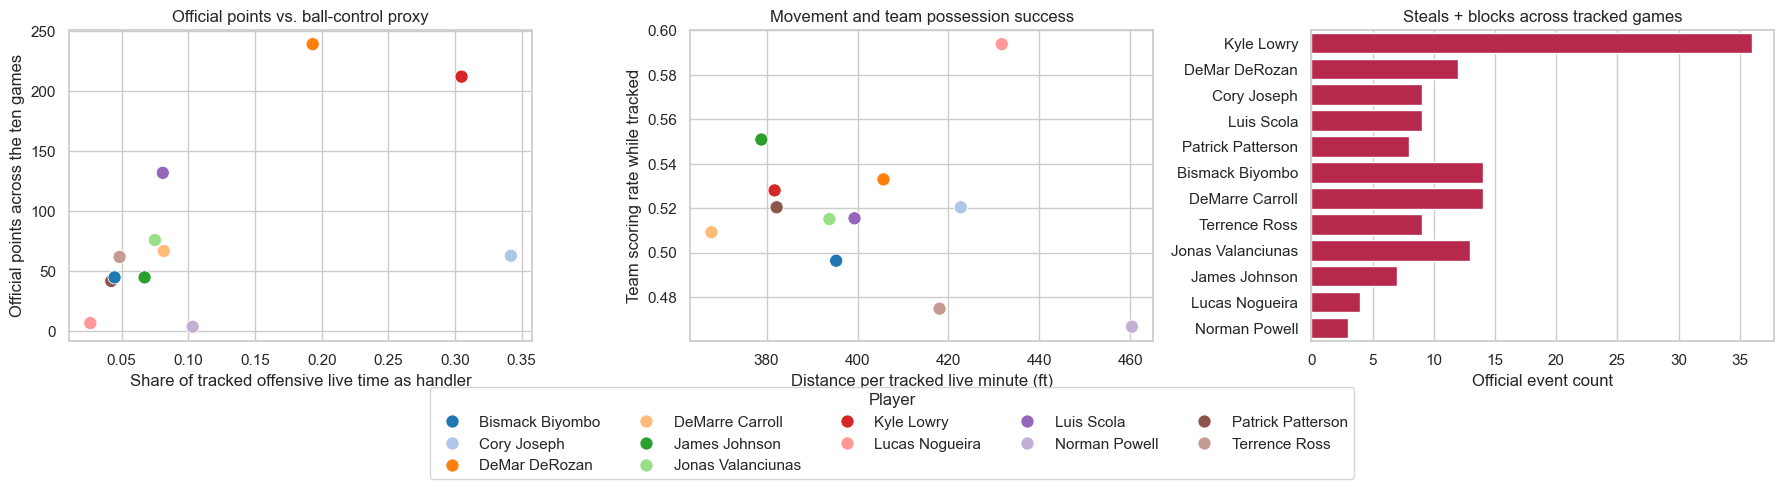

In [37]:
# Within-player comparison: movement and ball control in scored versus failed possessions.
minimum_possessions_per_outcome = 5
success_split = (
    player_possession_metrics.loc[player_possession_metrics["outcome_eligible"]]
    .groupby(["player_name", "scored"], as_index=False)
    .agg(
        possessions=("possession_number", "size"),
        mean_handler_seconds=("handler_seconds", "mean"),
        mean_distance_ft=("distance_traveled_ft", "mean"),
        mean_speed_ft_s=("average_speed_ft_s", "mean"),
        mean_distance_to_ball_ft=("mean_distance_to_ball_ft", "mean"),
    )
)
success_split = success_split.loc[
    success_split["possessions"].ge(minimum_possessions_per_outcome)
]
display(success_split.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_data = player_summary.loc[
    player_summary["offensive_possessions_tracked"].ge(20)
].copy()
player_order = sorted(plot_data["player_name"].dropna().unique())
player_palette = dict(
    zip(player_order, sns.color_palette("tab20", n_colors=len(player_order)))
)

sns.scatterplot(
    data=plot_data,
    x="handler_share",
    y="points",
    hue="player_name",
    hue_order=player_order,
    palette=player_palette,
    s=90,
    edgecolor="white",
    linewidth=0.6,
    ax=axes[0],
    legend="full",
)
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
axes[0].set_title("Official points vs. ball-control proxy")
axes[0].set_xlabel("Share of tracked offensive live time as handler")
axes[0].set_ylabel("Official points across the ten games")

sns.scatterplot(
    data=plot_data,
    x="distance_per_live_minute_ft",
    y="team_scoring_rate_on_court",
    hue="player_name",
    hue_order=player_order,
    palette=player_palette,
    s=90,
    edgecolor="white",
    linewidth=0.6,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Movement and team possession success")
axes[1].set_xlabel("Distance per tracked live minute (ft)")
axes[1].set_ylabel("Team scoring rate while tracked")

stocks = plot_data.assign(stocks=plot_data["steals"] + plot_data["blocks"])
sns.barplot(data=stocks, y="player_name", x="stocks", ax=axes[2], color="#CE1141")
axes[2].set_title("Steals + blocks across tracked games")
axes[2].set_xlabel("Official event count")
axes[2].set_ylabel("")

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        title="Player",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=min(5, len(legend_labels)),
        frameon=True,
    )
plt.tight_layout(rect=[0, 0.17, 1, 1])

## Player spatial profiles

Every spatial panel is drawn over `court.jpg` using attacking coordinates, so Toronto's common offensive basket is on the right. The first figure describes where the selected player was located during Toronto possessions. Each 2-by-2-foot bin is weighted by valid live time and normalized within the scored or failed outcome panel. It does not attribute the possession outcome to that location.

For player $p$, outcome $y$, spatial bin $b$, and valid live interval $\Delta t_t$, the displayed share is

\[
H_{pyb}=\frac{\sum_t \Delta t_t\,\mathbf{1}(p_t=p,\,Y_i=y,\,(x_{pt},y_{pt})\in b)}{\sum_t \Delta t_t\,\mathbf{1}(p_t=p,\,Y_i=y)}.
\]

Zero-exposure bins are transparent so the court remains visible. Both outcome panels use one colour scale; the colour bar is the fraction of the relevant tracked player time in a bin.

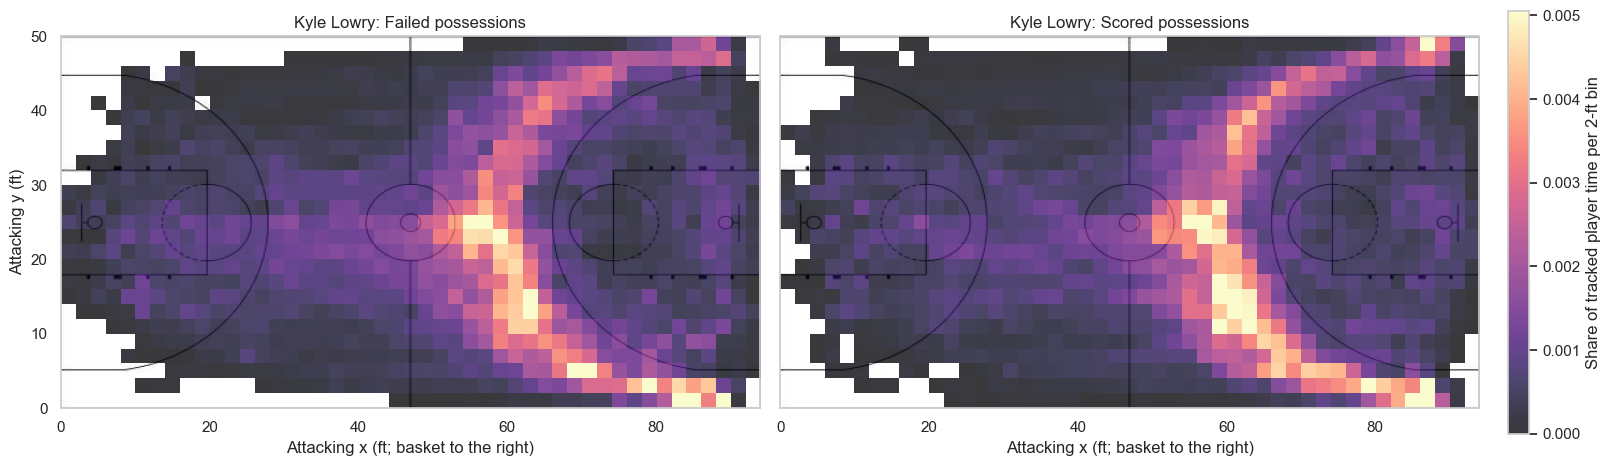

In [38]:
PLAYER_TO_PLOT = None  # Example: "Kyle Lowry". None selects the largest tracked sample.
if PLAYER_TO_PLOT is None:
    PLAYER_TO_PLOT = player_summary.iloc[0]["player_name"]

SPATIAL_BINS = (47, 25)  # 2 ft by 2 ft on a 94 ft by 50 ft court.
COURT_EXTENT = (0.0, COURT_LENGTH_FT, 0.0, COURT_WIDTH_FT)
court_image = plt.imread(COURT_IMAGE_PATH)


def normalized_time_heatmap(
    frame: pd.DataFrame,
    x_column: str,
    y_column: str,
    weight_column: str = "live_dt",
) -> np.ndarray:
    """Return each bin's share of valid tracked time for the supplied frame."""
    heatmap, _, _ = np.histogram2d(
        frame[x_column],
        frame[y_column],
        bins=SPATIAL_BINS,
        range=((0, COURT_LENGTH_FT), (0, COURT_WIDTH_FT)),
        weights=frame[weight_column],
    )
    total_weight = heatmap.sum()
    return heatmap / total_weight if total_weight > 0 else heatmap


def shared_positive_vmax(heatmaps: list[np.ndarray]) -> float:
    """Use a robust common scale while excluding structurally empty bins."""
    positive = np.concatenate([heatmap[heatmap > 0] for heatmap in heatmaps])
    return float(np.quantile(positive, 0.99)) if positive.size else 1.0


def draw_court_heatmap(
    ax,
    heatmap: np.ndarray,
    vmax: float,
    title: str,
):
    """Overlay a normalized time heatmap on the project court image."""
    ax.imshow(
        court_image,
        extent=COURT_EXTENT,
        aspect="auto",
        zorder=0,
    )
    masked = np.ma.masked_less_equal(heatmap.T, 0)
    image = ax.imshow(
        masked,
        origin="lower",
        extent=COURT_EXTENT,
        aspect="auto",
        cmap="magma",
        interpolation="nearest",
        alpha=0.78,
        vmin=0,
        vmax=vmax,
        zorder=1,
    )
    ax.set_xlim(0, COURT_LENGTH_FT)
    ax.set_ylim(0, COURT_WIDTH_FT)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel("Attacking x (ft; basket to the right)")
    return image


player_plot_data = player_live.loc[
    player_live["player_name"].eq(PLAYER_TO_PLOT)
    & player_live["valid_live_interval"]
].copy()

outcome_specs = [(0, "Failed"), (1, "Scored")]
outcome_heatmaps = [
    normalized_time_heatmap(
        player_plot_data.loc[player_plot_data["scored"].eq(scored_value)],
        "x_attack",
        "y_attack",
    )
    for scored_value, _ in outcome_specs
]
outcome_vmax = shared_positive_vmax(outcome_heatmaps)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
heat_image = None
for (scored_value, label), heatmap, ax in zip(
    outcome_specs, outcome_heatmaps, axes
):
    heat_image = draw_court_heatmap(
        ax,
        heatmap,
        outcome_vmax,
        f"{PLAYER_TO_PLOT}: {label} possessions",
    )
axes[0].set_ylabel("Attacking y (ft)")
fig.colorbar(
    heat_image,
    ax=axes,
    shrink=0.86,
    pad=0.02,
    label="Share of tracked player time per 2-ft bin",
)

### Four-foot ball-control location heatmaps

These panels use the explicit 4-foot proxy, regardless of any later change to `BALL_CONTROL_RADIUS_FT`. At valid live moment $t$, player $p$ is the handler when that player is the nearest Raptor, the planar player-ball distance is at most 4 feet, and ball height is at most 8 feet. The plotted coordinate is the **ball location**, not the player's feet.

For player $p$ and court bin $b$,

\[
H^{control}_{pb}=\frac{\sum_t \Delta t_t\,\mathbf{1}(handler_t=p,\,(x^{ball}_t,y^{ball}_t)\in b)}{\sum_t \Delta t_t\,\mathbf{1}(handler_t=p)}.
\]

Thus every player's heatmap sums to one over observed bins. A shared colour scale permits comparison of concentration, while the title reports total assigned seconds to show sample size. These are proximity-based control locations, not official NBA touches.

**`handler_spatial_summary_display` column guide**

- `player_name`: roster name used for interpretation; ID remains internal.
- `games_with_control`: tracked games containing at least one valid 4-foot assignment.
- `possessions_with_control`: distinct game-period-possession units in which the player received an assignment.
- `assigned_snapshots`: physical snapshots assigned to the player; this is sampling frequency, not elapsed time.
- `handler_seconds`: valid live seconds assigned to the player under the 4-foot rule.
- `team_assigned_handler_time_share`: player's handler seconds divided by all assigned Raptors handler seconds.
- `offensive_half_handler_share`: fraction of that player's handler seconds with the ball at `x >= 47`.
- `paint_handler_share`: fraction of that player's handler seconds with the ball in the approximate right-side paint (`x >= 75`, `17 <= y <= 33`).

,player_name,games_with_control,possessions_with_control,assigned_snapshots,handler_seconds,team_assigned_handler_time_share,offensive_half_handler_share,paint_handler_share
0,Kyle Lowry,10,559,84302,3371.85,0.320,0.684,0.031
1,Cory Joseph,10,316,62344,2496.08,0.237,0.702,0.037
2,DeMar DeRozan,10,443,51121,2049.11,0.194,0.872,0.082
3,Luis Scola,10,268,14766,591.62,0.056,0.904,0.168
4,DeMarre Carroll,6,198,12674,507.13,0.048,0.849,0.111
5,Jonas Valanciunas,6,204,9515,380.50,0.036,0.805,0.269
6,Bismack Biyombo,10,220,7201,287.99,0.027,0.772,0.351
7,Patrick Patterson,10,184,6917,276.63,0.026,0.830,0.055
8,Terrence Ross,9,121,6235,249.91,0.024,0.845,0.069
9,James Johnson,7,107,6037,241.90,0.023,0.861,0.155


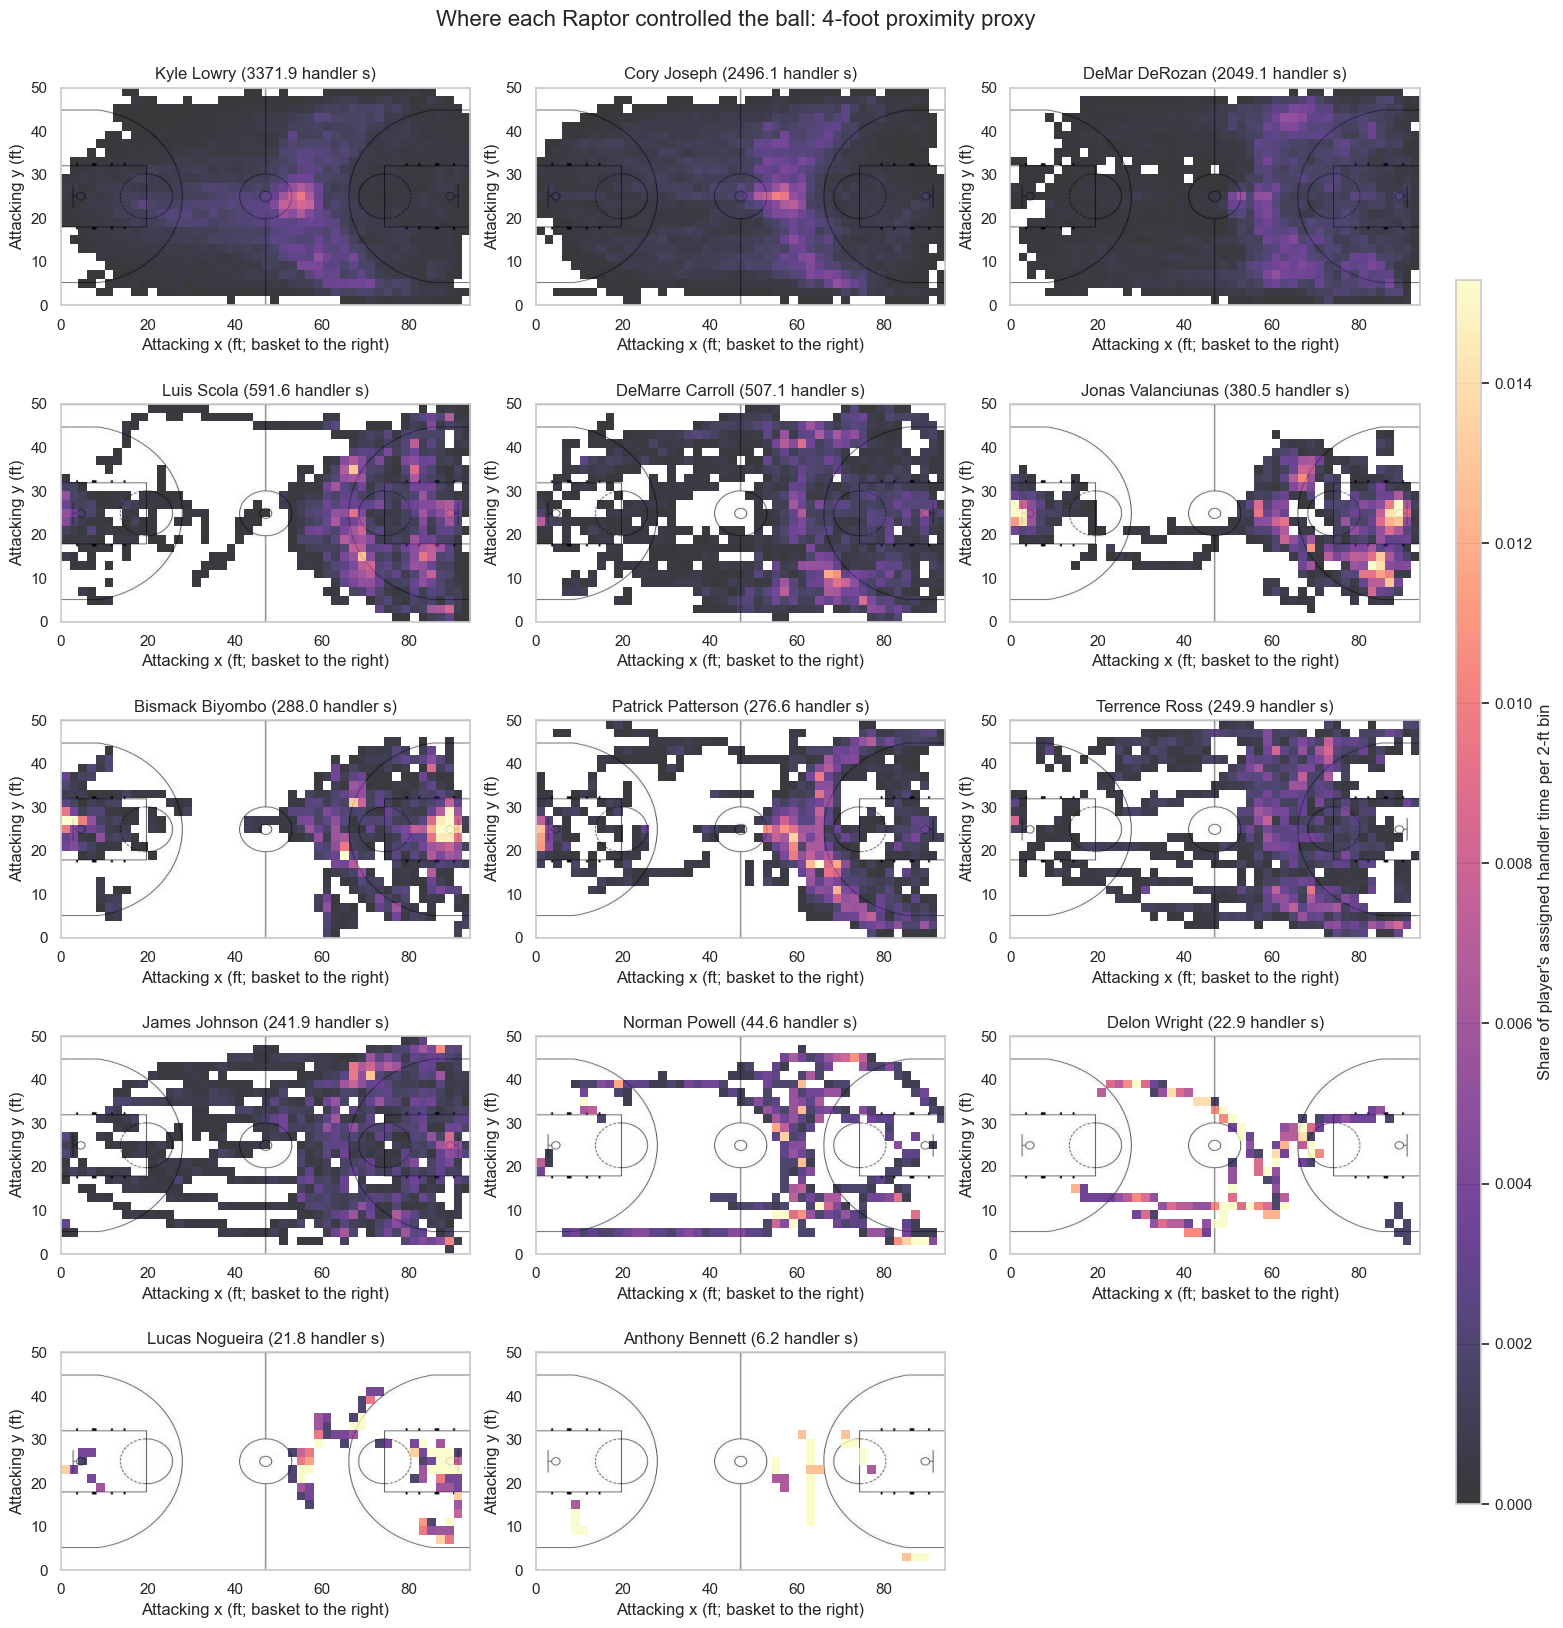

In [39]:
handler_radius_column = "handler_player_id_4ft"
tracking_name_lookup = (
    player_tracking[["player_id", "player_name"]]
    .drop_duplicates("player_id")
    .set_index("player_id")["player_name"]
    .to_dict()
)

handler_locations_4ft = snapshots.loc[
    snapshots["valid_live_interval"]
    & snapshots[handler_radius_column].notna()
    & snapshots["live_dt"].gt(0),
    SNAPSHOT_KEY
    + [
        "live_dt",
        "ball_x",
        "ball_y",
        "ball_z",
        "scored",
        handler_radius_column,
    ],
].copy()
handler_locations_4ft["player_id"] = handler_locations_4ft[
    handler_radius_column
].astype("int64")
handler_locations_4ft["player_name"] = handler_locations_4ft["player_id"].map(
    tracking_name_lookup
)
if handler_locations_4ft["player_name"].isna().any():
    raise ValueError("A 4-foot handler ID has no Raptors roster name.")

handler_locations_4ft["offensive_half_handler_seconds"] = (
    handler_locations_4ft["live_dt"]
    .where(handler_locations_4ft["ball_x"].ge(47), 0.0)
)
handler_locations_4ft["paint_handler_seconds"] = (
    handler_locations_4ft["live_dt"].where(
        handler_locations_4ft["ball_x"].ge(75)
        & handler_locations_4ft["ball_y"].between(17, 33),
        0.0,
    )
)

handler_possession_counts = (
    handler_locations_4ft[
        POSSESSION_KEY + ["player_id", "player_name"]
    ]
    .drop_duplicates()
    .groupby(["player_id", "player_name"], as_index=False)
    .size()
    .rename(columns={"size": "possessions_with_control"})
)
handler_spatial_summary = (
    handler_locations_4ft.groupby(
        ["player_id", "player_name"], as_index=False
    )
    .agg(
        games_with_control=("game_id", "nunique"),
        assigned_snapshots=("timestamp_ms", "size"),
        handler_seconds=("live_dt", "sum"),
        offensive_half_handler_seconds=(
            "offensive_half_handler_seconds",
            "sum",
        ),
        paint_handler_seconds=("paint_handler_seconds", "sum"),
    )
    .merge(
        handler_possession_counts,
        on=["player_id", "player_name"],
        how="left",
        validate="one_to_one",
    )
)
handler_spatial_summary["team_assigned_handler_time_share"] = (
    handler_spatial_summary["handler_seconds"]
    / handler_spatial_summary["handler_seconds"].sum()
)
handler_spatial_summary["offensive_half_handler_share"] = (
    handler_spatial_summary["offensive_half_handler_seconds"]
    / handler_spatial_summary["handler_seconds"]
)
handler_spatial_summary["paint_handler_share"] = (
    handler_spatial_summary["paint_handler_seconds"]
    / handler_spatial_summary["handler_seconds"]
)
handler_spatial_summary = handler_spatial_summary.sort_values(
    "handler_seconds", ascending=False
).reset_index(drop=True)

handler_spatial_summary_display = handler_spatial_summary[
    [
        "player_name",
        "games_with_control",
        "possessions_with_control",
        "assigned_snapshots",
        "handler_seconds",
        "team_assigned_handler_time_share",
        "offensive_half_handler_share",
        "paint_handler_share",
    ]
]
display(handler_spatial_summary_display.round(3))

handler_heatmaps = {}
for player_id in handler_spatial_summary["player_id"]:
    player_handler_locations = handler_locations_4ft.loc[
        handler_locations_4ft["player_id"].eq(player_id)
    ]
    handler_heatmaps[int(player_id)] = normalized_time_heatmap(
        player_handler_locations,
        "ball_x",
        "ball_y",
    )

n_players = len(handler_spatial_summary)
if n_players == 0:
    raise ValueError("No valid 4-foot ball-control assignments were found.")
handler_vmax = shared_positive_vmax(list(handler_heatmaps.values()))
n_columns = 3
n_rows = math.ceil(n_players / n_columns)
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(18, 3.6 * n_rows),
    squeeze=False,
)

heat_image = None
for ax, player in zip(axes.flat, handler_spatial_summary.itertuples(index=False)):
    heat_image = draw_court_heatmap(
        ax,
        handler_heatmaps[int(player.player_id)],
        handler_vmax,
        f"{player.player_name} ({player.handler_seconds:.1f} handler s)",
    )
    ax.set_ylabel("Attacking y (ft)")
for ax in list(axes.flat)[n_players:]:
    ax.set_visible(False)

fig.suptitle(
    "Where each Raptor controlled the ball: 4-foot proximity proxy",
    fontsize=16,
)
fig.subplots_adjust(top=0.94, right=0.88, hspace=0.38, wspace=0.16)
colourbar_axis = fig.add_axes([0.90, 0.15, 0.014, 0.68])
fig.colorbar(
    heat_image,
    cax=colourbar_axis,
    label="Share of player's assigned handler time per 2-ft bin",
)

## Defensive actions and offensive scoring that follows

We distinguish four mechanisms:

- `steal_to_next_offense`: the player's steal starts the transition;
- `defensive_rebound_to_next_offense`: the player's defensive rebound secures the ball;
- `recovered_block_to_next_offense`: the player's block is followed by a Toronto steal or defensive rebound before the next offense;
- `offensive_rebound_second_chance`: the player extends a Toronto possession and points occur later in that possession.

For trigger (j), let (Y_j=1) if the linked opportunity scores. The descriptive rate is

\[
\widehat p_{trigger}=\frac{1}{n_{trigger}}\sum_jY_j,
\]

and the displayed difference is \(\widehat p_{trigger}-\widehat p_{all}\). This contrast is not adjusted for lineup, opponent, game state, or transition difficulty.

**`recovery_linkage_sensitivity` column guide**

- `maximum_alignment_gap_seconds`: allowed event-to-next-offense clock gap.
- `linked_recoveries`: steals and defensive rebounds receiving a qualifying next possession.
- `linkage_share`: linked recoveries divided by all eligible recovery events.

**Displayed `trigger_summary` column guide**

- `player_name`: player who generated the initiating action.
- `trigger_type`: steal, defensive rebound, recovered block, or offensive-rebound pathway defined above.
- `opportunities`: linked trigger events.
- `scoring_followups`: opportunities followed by points under that pathway's definition.
- `points_after_trigger`: total linked points.
- `mean_start_gap_seconds`: average recovery-to-offense-start gap; missing for same-possession offensive rebounds.
- `scoring_rate`: scoring followups divided by opportunities.
- `points_per_opportunity`: linked points divided by opportunities.
- `scoring_rate_minus_all_possessions`: descriptive difference from the eligible-possession baseline.

**`trigger_linkage_audit` guide**

The row labels identify the source-event or successfully linked subset; the sole `count` column gives its event total. Compare each linked row with its corresponding official-action row to assess linkage coverage.

In [40]:
def assign_events_to_raptors_possessions(
    event_frame: pd.DataFrame,
    possessions: pd.DataFrame,
    tolerance_seconds: float = 0.75,
) -> pd.DataFrame:
    """Assign events inside a Toronto interval; opponent-possession events stay null."""
    assigned_parts = []
    for (game_id, period), group in event_frame.groupby(["game_id", "PERIOD"]):
        candidates = possessions.loc[
            possessions["game_id"].eq(game_id)
            & possessions["period"].eq(period)
        ]
        group = group.copy()
        group["possession_number"] = pd.NA
        group["assignment_distance_seconds"] = np.nan
        for row in candidates.itertuples(index=False):
            event_time = group["event_elapsed_seconds"]
            start = row.start_elapsed_seconds
            end = row.end_elapsed_seconds
            inside = event_time.between(
                start - tolerance_seconds,
                end + tolerance_seconds,
                inclusive="both",
            )
            distance = np.maximum.reduce(
                [
                    (start - event_time).to_numpy(),
                    (event_time - end).to_numpy(),
                    np.zeros(len(group)),
                ]
            )
            replace = inside & (
                group["assignment_distance_seconds"].isna()
                | (distance < group["assignment_distance_seconds"])
            )
            group.loc[replace, "possession_number"] = int(row.possession_number)
            group.loc[replace, "assignment_distance_seconds"] = distance[replace]
        assigned_parts.append(group)
    assigned = pd.concat(assigned_parts, ignore_index=True)
    assigned["possession_number"] = assigned["possession_number"].astype("Int64")
    return assigned


outcome_possessions = analysis_possessions.loc[
    ~analysis_possessions["known_external_scoring_mismatch"]
].copy()
events_with_possession = assign_events_to_raptors_possessions(
    events, outcome_possessions
)
event_assignment = events_with_possession[
    ["game_id", "EVENTNUM", "possession_number", "assignment_distance_seconds"]
]
event_stats_linked = event_player_stats.merge(
    event_assignment,
    on=["game_id", "EVENTNUM"],
    how="left",
    validate="many_to_one",
)


def link_recovery_to_next_offense(
    recovery: pd.Series,
    possessions: pd.DataFrame,
    max_gap_seconds: float = MAX_RECOVERY_TO_OFFENSE_ALIGNMENT_GAP_SECONDS,
) -> pd.Series | None:
    candidates = possessions.loc[
        possessions["game_id"].eq(recovery["game_id"])
        & possessions["period"].eq(recovery["PERIOD"])
    ].copy()
    candidates["start_gap_seconds"] = (
        candidates["start_elapsed_seconds"] - recovery["event_elapsed_seconds"]
    )
    candidates = candidates.loc[
        candidates["start_gap_seconds"].between(-0.75, max_gap_seconds)
    ].sort_values(["start_gap_seconds", "possession_number"])
    if candidates.empty:
        return None
    return candidates.iloc[0]


trigger_rows = []
recoveries = event_stats_linked.loc[
    event_stats_linked["stat"].isin(["steals", "defensive_rebounds"])
].sort_values(["game_id", "EVENTNUM"])

recovery_linkage_sensitivity = []
for maximum_gap in [3.0, 5.0, 8.0, 12.0]:
    linked_count = sum(
        link_recovery_to_next_offense(
            pd.Series(recovery),
            outcome_possessions,
            max_gap_seconds=maximum_gap,
        )
        is not None
        for recovery in recoveries.to_dict("records")
    )
    recovery_linkage_sensitivity.append(
        {
            "maximum_alignment_gap_seconds": maximum_gap,
            "linked_recoveries": linked_count,
            "linkage_share": linked_count / len(recoveries),
        }
    )
display(pd.DataFrame(recovery_linkage_sensitivity).round(3))

linked_recovery_keys = {}
for recovery in recoveries.to_dict("records"):
    recovery_series = pd.Series(recovery)
    possession = link_recovery_to_next_offense(
        recovery_series, outcome_possessions
    )
    if possession is None:
        continue
    trigger_type = (
        "steal_to_next_offense"
        if recovery["stat"] == "steals"
        else "defensive_rebound_to_next_offense"
    )
    linked_recovery_keys[(recovery["game_id"], recovery["EVENTNUM"])] = possession
    trigger_rows.append(
        {
            "game_id": recovery["game_id"],
            "period": recovery["PERIOD"],
            "possession_number": int(possession["possession_number"]),
            "player_id": int(recovery["player_id"]),
            "player_name": recovery["player_name"],
            "trigger_eventnum": int(recovery["EVENTNUM"]),
            "trigger_type": trigger_type,
            "scored": int(possession["scored"]),
            "points_after_trigger": int(possession["points_scored"]),
            "start_gap_seconds": float(possession["start_gap_seconds"]),
        }
    )

# A block is retained only when Toronto subsequently records a steal or defensive
# rebound and that recovery is already linked to the next offensive possession.
blocks = event_player_stats.loc[event_player_stats["stat"].eq("blocks")]
for block in blocks.to_dict("records"):
    later_recovery = recoveries.loc[
        recoveries["game_id"].eq(block["game_id"])
        & recoveries["PERIOD"].eq(block["PERIOD"])
        & recoveries["EVENTNUM"].gt(block["EVENTNUM"])
        & recoveries["event_elapsed_seconds"].sub(
            block["event_elapsed_seconds"]
        ).between(0, 5)
    ].sort_values("EVENTNUM")
    if later_recovery.empty:
        continue
    recovery = later_recovery.iloc[0]
    possession = linked_recovery_keys.get(
        (recovery["game_id"], recovery["EVENTNUM"])
    )
    if possession is None:
        continue
    trigger_rows.append(
        {
            "game_id": block["game_id"],
            "period": block["PERIOD"],
            "possession_number": int(possession["possession_number"]),
            "player_id": int(block["player_id"]),
            "player_name": block["player_name"],
            "trigger_eventnum": int(block["EVENTNUM"]),
            "trigger_type": "recovered_block_to_next_offense",
            "scored": int(possession["scored"]),
            "points_after_trigger": int(possession["points_scored"]),
            "start_gap_seconds": float(possession["start_gap_seconds"]),
        }
    )

# Offensive rebounds must be mapped to a Raptors possession, and only points at a
# later EVENTNUM count as second-chance points for this descriptive link.
offensive_rebounds = event_stats_linked.loc[
    event_stats_linked["stat"].eq("offensive_rebounds")
    & event_stats_linked["possession_number"].notna()
]
scoring_events = event_stats_linked.loc[
    event_stats_linked["stat"].eq("points")
    & event_stats_linked["possession_number"].notna()
]
for rebound in offensive_rebounds.to_dict("records"):
    later_points = scoring_events.loc[
        scoring_events["game_id"].eq(rebound["game_id"])
        & scoring_events["PERIOD"].eq(rebound["PERIOD"])
        & scoring_events["possession_number"].eq(rebound["possession_number"])
        & scoring_events["EVENTNUM"].gt(rebound["EVENTNUM"]),
        "value",
    ].sum()
    trigger_rows.append(
        {
            "game_id": rebound["game_id"],
            "period": rebound["PERIOD"],
            "possession_number": int(rebound["possession_number"]),
            "player_id": int(rebound["player_id"]),
            "player_name": rebound["player_name"],
            "trigger_eventnum": int(rebound["EVENTNUM"]),
            "trigger_type": "offensive_rebound_second_chance",
            "scored": int(later_points > 0),
            "points_after_trigger": int(later_points),
            "start_gap_seconds": np.nan,
        }
    )

scoring_triggers = pd.DataFrame(trigger_rows)
baseline_scoring_rate = outcome_possessions["scored"].mean()
trigger_summary = (
    scoring_triggers.groupby(
        ["player_id", "player_name", "trigger_type"], as_index=False
    )
    .agg(
        opportunities=("trigger_eventnum", "size"),
        scoring_followups=("scored", "sum"),
        points_after_trigger=("points_after_trigger", "sum"),
        mean_start_gap_seconds=("start_gap_seconds", "mean"),
    )
)
trigger_summary["scoring_rate"] = (
    trigger_summary["scoring_followups"] / trigger_summary["opportunities"]
)
trigger_summary["points_per_opportunity"] = (
    trigger_summary["points_after_trigger"] / trigger_summary["opportunities"]
)
trigger_summary["scoring_rate_minus_all_possessions"] = (
    trigger_summary["scoring_rate"] - baseline_scoring_rate
)

display(
    trigger_summary.drop(columns="player_id")
    .sort_values(["trigger_type", "opportunities"], ascending=[True, False])
    .round(3)
)

trigger_linkage_audit = pd.Series(
    {
        "official steals + defensive rebounds": len(recoveries),
        "recoveries linked to a next offense": int(
            scoring_triggers["trigger_type"].isin(
                ["steal_to_next_offense", "defensive_rebound_to_next_offense"]
            ).sum()
        ),
        "official blocks": len(blocks),
        "blocks followed by a linked Toronto recovery": int(
            scoring_triggers["trigger_type"].eq(
                "recovered_block_to_next_offense"
            ).sum()
        ),
        "official offensive rebounds": int(
            event_player_stats["stat"].eq("offensive_rebounds").sum()
        ),
        "offensive rebounds mapped to current possession intervals": len(
            offensive_rebounds
        ),
    },
    name="count",
)
display(trigger_linkage_audit.to_frame())

,maximum_alignment_gap_seconds,linked_recoveries,linkage_share
0,3.0,114,0.260
1,5.0,185,0.421
2,8.0,280,0.638
3,12.0,407,0.927


,player_name,trigger_type,opportunities,scoring_followups,points_after_trigger,mean_start_gap_seconds,scoring_rate,points_per_opportunity,scoring_rate_minus_all_possessions
26,Bismack Biyombo,defensive_rebound_to_next_offense,56,29,62,5.716,0.518,1.107,0.002
0,Luis Scola,defensive_rebound_to_next_offense,43,24,53,6.849,0.558,1.233,0.042
4,Kyle Lowry,defensive_rebound_to_next_offense,43,25,51,6.175,0.581,1.186,0.065
8,DeMar DeRozan,defensive_rebound_to_next_offense,42,18,37,4.400,0.429,0.881,-0.087
22,Jonas Valanciunas,defensive_rebound_to_next_offense,38,23,46,6.186,0.605,1.211,0.089
19,Patrick Patterson,defensive_rebound_to_next_offense,31,19,37,5.125,0.613,1.194,0.097
15,DeMarre Carroll,defensive_rebound_to_next_offense,22,15,32,4.584,0.682,1.455,0.166
30,Cory Joseph,defensive_rebound_to_next_offense,15,6,13,5.499,0.400,0.867,-0.116
11,James Johnson,defensive_rebound_to_next_offense,14,10,22,7.650,0.714,1.571,0.198
34,Terrence Ross,defensive_rebound_to_next_offense,13,8,17,6.067,0.615,1.308,0.099


,count
official steals + defensive rebounds,439
recoveries linked to a next offense,407
official blocks,56
blocks followed by a linked Toronto recovery,29
official offensive rebounds,92
offensive rebounds mapped to current possession intervals,85


## Lineup context

A possession can contain substitutions at stopped clocks. To avoid crediting full possession points to multiple lineups, the primary lineup is the five-player unit with the greatest valid live time in that possession.

**`lineup_summary` column guide**

- `lineup_name`: five player names separated by `|`, ordered by internal player ID for stable grouping.
- `possessions`: possessions for which this unit supplied the most valid live time.
- `outcome_eligible_possessions`: those possessions after excluding documented scoring-label mismatches.
- `live_seconds`: dominant-lineup live time, not full game or full-possession time.
- `current_label_points`: team points over eligible possessions using the loaded possession labels.
- `scoring_rate`: fraction of eligible primary-lineup possessions that scored.

In [41]:
name_lookup = (
    rosters.loc[rosters["team_id"].eq(RAPTORS_TEAM_ID), ["player_id", "player_name"]]
    .drop_duplicates("player_id")
    .set_index("player_id")["player_name"]
    .to_dict()
)

lineup_members = (
    player_live.groupby(SNAPSHOT_KEY)["player_id"]
    .agg(lambda values: tuple(sorted(int(value) for value in values.unique())))
    .rename("lineup_ids")
    .reset_index()
)
lineup_members["lineup_name"] = lineup_members["lineup_ids"].map(
    lambda ids: " | ".join(name_lookup.get(player_id, str(player_id)) for player_id in ids)
)
lineup_time = lineup_members.merge(
    snapshots[SNAPSHOT_KEY + ["live_dt"]],
    on=SNAPSHOT_KEY,
    how="left",
    validate="one_to_one",
)
lineup_possession_time = (
    lineup_time.groupby(POSSESSION_KEY + ["lineup_name"], as_index=False)["live_dt"]
    .sum()
)
primary_lineup_index = lineup_possession_time.groupby(POSSESSION_KEY)["live_dt"].idxmax()
primary_lineups = lineup_possession_time.loc[primary_lineup_index].merge(
    analysis_possessions[
        POSSESSION_KEY
        + ["points_scored", "scored", "known_external_scoring_mismatch"]
    ],
    on=POSSESSION_KEY,
    how="left",
    validate="one_to_one",
)
primary_lineups["outcome_eligible"] = ~primary_lineups[
    "known_external_scoring_mismatch"
]
primary_lineups["points_for_summary"] = primary_lineups["points_scored"].where(
    primary_lineups["outcome_eligible"]
)
primary_lineups["scored_for_summary"] = primary_lineups["scored"].where(
    primary_lineups["outcome_eligible"]
)
lineup_summary = (
    primary_lineups.groupby("lineup_name", as_index=False)
    .agg(
        possessions=("possession_number", "size"),
        outcome_eligible_possessions=("outcome_eligible", "sum"),
        live_seconds=("live_dt", "sum"),
        current_label_points=("points_for_summary", "sum"),
        scoring_rate=("scored_for_summary", "mean"),
    )
    .sort_values("possessions", ascending=False)
)
display(lineup_summary.head(20).round(3))

,lineup_name,possessions,outcome_eligible_possessions,live_seconds,current_label_points,scoring_rate
60,Luis Scola | Kyle Lowry | DeMar DeRozan | DeMa...,112,112,1810.55,128.0,0.536
58,Luis Scola | Kyle Lowry | DeMar DeRozan | DeMa...,63,63,1142.16,61.0,0.444
64,Luis Scola | Kyle Lowry | DeMar DeRozan | Jame...,61,61,923.04,72.0,0.508
10,DeMar DeRozan | Patrick Patterson | Bismack Bi...,39,39,650.08,28.0,0.359
63,Luis Scola | Kyle Lowry | DeMar DeRozan | Jame...,37,37,619.20,48.0,0.568
28,Kyle Lowry | DeMar DeRozan | Patrick Patterson...,35,35,571.70,43.0,0.571
42,Kyle Lowry | Patrick Patterson | Bismack Biyom...,31,30,457.99,28.0,0.433
57,Luis Scola | Kyle Lowry | DeMar DeRozan | Bism...,30,30,491.11,32.0,0.533
23,Kyle Lowry | DeMar DeRozan | DeMarre Carroll |...,22,22,332.67,27.0,0.636
31,Kyle Lowry | DeMar DeRozan | Patrick Patterson...,20,20,348.53,26.0,0.600


## Final quality-control checklist

Run these checks before interpreting the figures:

- event-derived player points equal the ten source-game Raptors point totals;
- every displayed player has one stable name per ID;
- one physical timestamp belongs to at most one offensive possession;
- exact-five lineup coverage is reported rather than silently imputed;
- ball-control assignment coverage is shown at three radii;
- rejected movement steps and missing-feed possessions remain visible;
- primary all-represented results are compared with the current 758-possession cohort;
- transition metrics are described as associations, never causal credit.

**`quality_control` guide**

The row labels name a validation condition or coverage count and the sole `count` column reports its value. Reconciliation differences, multiple-name IDs, duplicate assigned snapshots, and conflicting raw timestamps should ideally be zero. The remaining rows quantify expected exclusions or coverage and require substantive review rather than an automatic zero target.

**`cohort_sensitivity` column guide**

- `player_name`: displayed roster name.
- `current_half_court_keep`: `True` for the historical retained cohort and `False` for historically removed possessions.
- `possessions`: player-possession observations in that subgroup.
- `scoring_rate`: fraction of those team possessions that scored.
- `mean_handler_seconds`: average 4-foot proxy control time per player-possession.
- `mean_distance_ft`: average accepted movement distance per player-possession.

In [42]:
name_consistency = (
    pd.concat(
        [
            rosters[["player_id", "player_name"]],
            event_player_stats[["player_id", "player_name"]],
        ],
        ignore_index=True,
    )
    .dropna()
    .groupby("player_id")["player_name"]
    .nunique()
)

quality_control = pd.Series(
    {
        "point reconciliation differences": int(
            point_reconciliation["difference"].ne(0).sum()
        ),
        "tracked possessions excluded from outcome contrasts": int(
            analysis_possessions["known_external_scoring_mismatch"].sum()
        ),
        "player IDs with multiple names": int(name_consistency.gt(1).sum()),
        "duplicate assigned snapshots": int(snapshots.duplicated(SNAPSHOT_KEY).sum()),
        "snapshots without exactly five Raptors": int(
            (~snapshots["valid_five_player_lineup"]).sum()
        ),
        "possessions requested": len(analysis_possessions),
        "possessions represented after physical parsing": int(
            tracking_coverage["represented"].sum()
        ),
        "conflicting duplicate raw timestamps": int(
            tracking_file_audit["conflicting_timestamps"].sum()
        ),
        "movement steps rejected": int(
            (~player_live["valid_movement_step"] & player_live["valid_live_interval"]).sum()
        ),
    },
    name="count",
)
display(quality_control.to_frame())

cohort_sensitivity = (
    player_possession_metrics.groupby(
        ["player_name", "current_half_court_keep"], as_index=False
    )
    .agg(
        possessions=("possession_number", "size"),
        scoring_rate=("scored", "mean"),
        mean_handler_seconds=("handler_seconds", "mean"),
        mean_distance_ft=("distance_traveled_ft", "mean"),
    )
)
display(cohort_sensitivity.round(3))

,count
point reconciliation differences,2
tracked possessions excluded from outcome contrasts,2
player IDs with multiple names,0
duplicate assigned snapshots,0
snapshots without exactly five Raptors,3
possessions requested,882
possessions represented after physical parsing,882
conflicting duplicate raw timestamps,1
movement steps rejected,543


,player_name,current_half_court_keep,possessions,scoring_rate,mean_handler_seconds,mean_distance_ft
0,Anthony Bennett,True,9,0.556,0.693,79.720
1,Bismack Biyombo,False,61,0.246,0.581,136.647
2,Bismack Biyombo,True,351,0.538,0.719,97.358
3,Cory Joseph,False,65,0.262,7.712,152.325
4,Cory Joseph,True,404,0.559,4.938,102.816
5,DeMar DeRozan,False,98,0.276,3.118,142.528
6,DeMar DeRozan,True,571,0.576,3.054,101.130
7,DeMarre Carroll,False,60,0.233,1.605,135.803
8,DeMarre Carroll,True,323,0.560,1.272,92.814
9,Delon Wright,True,5,0.200,4.576,112.579


## How to read the outputs

1. Start with `quality_control`, `tracking_coverage`, and `control_sensitivity`. Do not interpret a player table if these reveal poor coverage.
2. Use `boxscore_all_games` for official actions and `player_tracking_summary` for spatial exposure. They measure different things and remain separate until the explicitly labeled combined summary.
3. Compare players only with adequate tracked possessions. Raw official totals reward availability. Do not divide complete-game box-score totals by the smaller tracking cohort without first restricting the events to the same support.
4. Interpret ball-control time as a nearest-player proximity estimate. Report the 3/4/5-foot sensitivity when it matters.
5. Treat scored-versus-failed movement differences as exploratory. Faster or longer movement may be a consequence of possession type rather than a cause of scoring.
6. Treat steal/rebound/block follow-ups as transition descriptions. A future player-effect model should adjust for lineup, opponent, possession state, and spatial opportunity using the QUT methodology.